## Les bibliothéques utilisées

In [1]:

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn


### Paramétres de choc

In [2]:
# Paramètres du choc
A = 0.2
x0 = 0.0
sigma = 1.0
D = 1.0
alpha = 0.1
L = 10
T = 5
Nx = 200
clf = 0.45

## Solution analytique(exact)

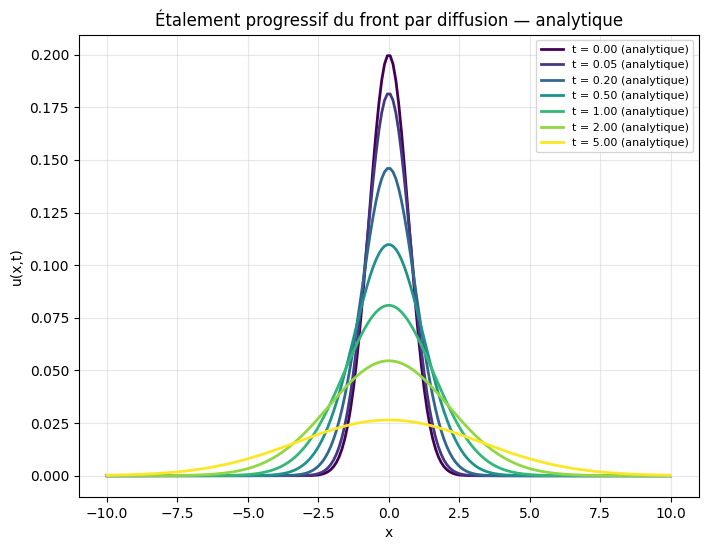

In [3]:

def u_analytique (x , t , A =0.2 , x0 =0.0 , sigma =1.0 , D =1.0 , alpha =0.1) :
#""" Solution analytique avec condition initiale gaussienne . """
  denom = np.sqrt (1 + (4* D * t / sigma **2))
  exp_part = np . exp ( -( x - x0 ) **2 / ( sigma **2 + 4* D * t ) )
  return A / denom * exp_part * np . exp ( - alpha * t )
# Paramètres
Nt = 100
x_Analytique = np . linspace ( -L , L , Nx )
t = np . linspace (0 , T , Nt )

# Calcul de la solution
U = np . zeros (( Nt , Nx ) )
# Précalcul de toute la matrice U (comme avant, mais sans plt dans la boucle)
for i, ti in enumerate(t):
    U[i, :] = u_analytique(x_Analytique, ti, A, x0, sigma, D, alpha)
    
plt.style.use('default')
fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')
    
temps_a_tracer = [1e-4, 0.05, 0.2, 0.5, 1, 2, T]
colors = plt.cm.viridis(np.linspace(0, 1, len(temps_a_tracer)))

for k, (ti, c) in enumerate(zip(temps_a_tracer, colors)):
    # Solution analytique (couleur dégradée selon t)
    ax.plot(x_Analytique, u_analytique(x_Analytique, ti, A,x0, sigma, D, alpha),
            color=c, linewidth=2, label=f"t = {ti:.2f} (analytique)")

ax.set_xlabel('x')
ax.set_ylabel('u(x,t)')
ax.set_title("Étalement progressif du front par diffusion — analytique")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.savefig('diffusion_analytique.png', dpi=300, bbox_inches='tight')
plt.show()

## Solution volumes finis

espace de temps 0.004500000000000001 espace de position 0.1


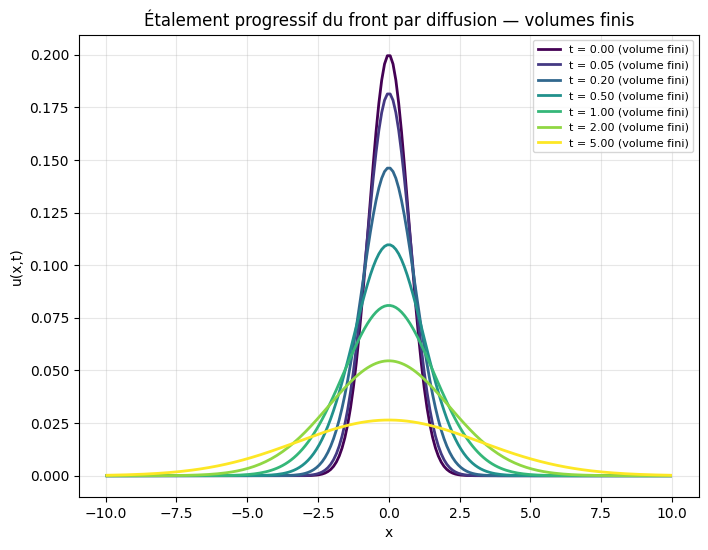

In [4]:

# Paramètres
def u_volume_finie(A =0.2 , x0 =0.0 , sigma =1.0 , D =1.0 , alpha =0.1 , L=L, T=T, Nx=Nx, clf=clf):
    """
    Résout l'équation de diffusion-amortissement par volumes finis.
    Retourne x_VF, t_VF, U_num pour pouvoir tracer ou comparer le résultat.
    """
    dx = 2 * L / Nx
    x_VF = -L + (np.arange(Nx) + 0.5) * dx
    dt = clf * dx**2 / D
    Nt = int(T / dt) + 1

    print("espace de temps", dt, "espace de position", dx)

    U_num = np.zeros((Nt, Nx))
    t_VF = np.linspace(0, T, Nt)
    U_num[0, :] = A * np.exp(-(x_VF - x0)**2 / sigma**2)
    r = D * dt / dx**2

    for i in range(Nt - 1):
        for j in range(1, Nx - 1):
            U_num[i+1, j] = U_num[i, j] + r * (U_num[i, j+1] - 2*U_num[i, j] + U_num[i, j-1]) - alpha * dt * U_num[i, j]
        U_num[i+1, 0] = u_analytique(-L, t_VF[i+1], A, x0, sigma, D, alpha)
        U_num[i+1, -1] = u_analytique(L, t_VF[i+1], A, x0, sigma, D, alpha)

    return x_VF, t_VF, U_num
x_VF, t_VF, U_num = u_volume_finie()
plt.style.use('default')
fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')
    
temps_a_tracer = [1e-4, 0.05, 0.2, 0.5, 1, 2, T]
colors = plt.cm.viridis(np.linspace(0, 1, len(temps_a_tracer)))

for k, (ti, c) in enumerate(zip(temps_a_tracer, colors)):
    

    # Solution numérique (volumes finis) : étoiles rouges
    idx = np.argmin(np.abs(t_VF - ti))
    ax.plot(x_VF, U_num[idx, :], linewidth=2, label=f"t = {ti:.2f} (volume fini)", color=c, )

ax.set_xlabel('x')
ax.set_ylabel('u(x,t)')
ax.set_title("Étalement progressif du front par diffusion — volumes finis")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.savefig('diffusion_VF.png', dpi=300, bbox_inches='tight')
plt.show()

### la visualisation des deux solutions

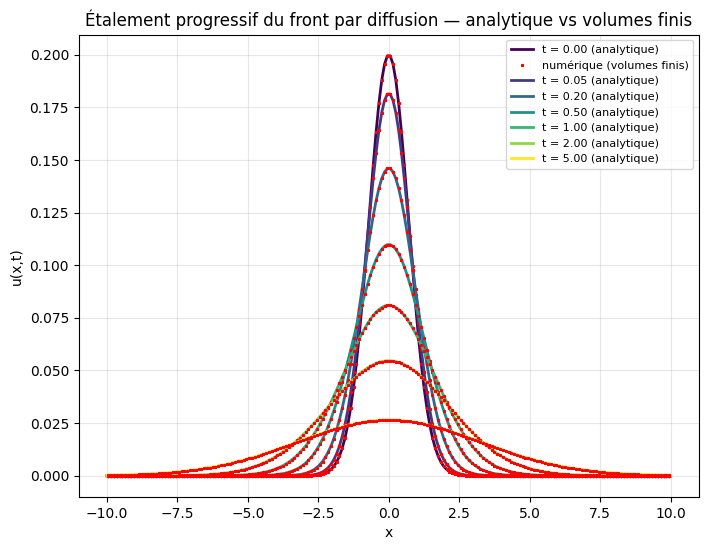

In [5]:
plt.style.use('default')
fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')
    
temps_a_tracer = [1e-4, 0.05, 0.2, 0.5, 1, 2, T]
colors = plt.cm.viridis(np.linspace(0, 1, len(temps_a_tracer)))

for k, (ti, c) in enumerate(zip(temps_a_tracer, colors)):
    # Solution analytique (couleur dégradée selon t)
    ax.plot(x_Analytique, u_analytique(x_Analytique, ti, A,x0, sigma, D, alpha),
            color=c, linewidth=2, label=f"t = {ti:.2f} (analytique)")

    # Solution numérique (volumes finis) : étoiles rouges
    idx = np.argmin(np.abs(t_VF - ti))
    ax.plot(x_VF, U_num[idx, :], color="red", marker='*', markersize=2,
             linestyle='none',
            label="numérique (volumes finis)" if k == 0 else None)

ax.set_xlabel('x')
ax.set_ylabel('u(x,t)')
ax.set_title("Étalement progressif du front par diffusion — analytique vs volumes finis")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.savefig('diffusion_analytique_vs_VF.png', dpi=300, bbox_inches='tight')
plt.show()

### l'erreur 

In [6]:
import numpy as np
dx = x_VF[1] - x_VF[0]
def erreurs_L2_Linf(x, U_num, U_exact, dx):
    """
    Calcule les erreurs L2 et L_infini entre solution numérique et exacte.
    U_num, U_exact : tableaux 1D de même taille (valeurs de u sur x)
    """
    diff = U_num - U_exact
    L2 = np.sqrt(dx * np.sum(diff**2))
    Linf = np.max(np.abs(diff))
    return L2, Linf

# Exemple à t donné
ti = 1.0
idx = np.argmin(np.abs(t_VF - ti))
U_exacte = u_analytique(x_VF, t_VF[idx], A, x0, sigma, D, alpha)
U_numerique = U_num[idx, :]

L2, Linf = erreurs_L2_Linf(x_VF, U_numerique, U_exacte, dx)
print(f"t = {ti:.2f}  |  L2 = {L2:.6f}  |  L∞ = {Linf:.6f}")

t = 1.00  |  L2 = 0.000094  |  L∞ = 0.000067


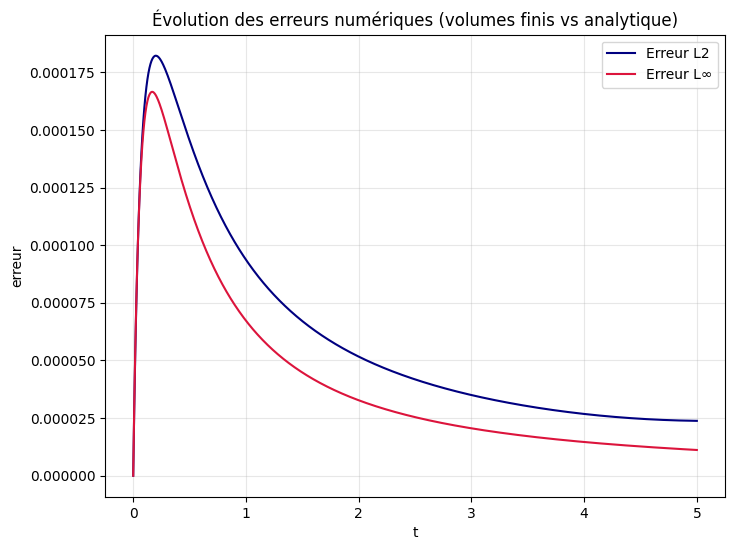

Erreur L2 max sur toute la simulation   : 0.000182
Erreur L∞ max sur toute la simulation   : 0.000167


In [7]:
L2_list = []
Linf_list = []


for n in range(t_VF.size):
    U_exacte_n = u_analytique(x_VF, t_VF[n], A, x0, sigma, D, alpha)
    U_num_n = U_num[n, :]
    L2_n, Linf_n = erreurs_L2_Linf(x_VF, U_num_n, U_exacte_n, dx)
    L2_list.append(L2_n)
    Linf_list.append(Linf_n)

L2_list = np.array(L2_list)
Linf_list = np.array(Linf_list)

# --- Graphe de l'évolution des erreurs ---
plt.figure(figsize=(8, 6))
plt.plot(t_VF, L2_list, label="Erreur L2", color='navy')
plt.plot(t_VF, Linf_list, label="Erreur L∞", color='crimson')
plt.xlabel('t')
plt.ylabel('erreur')
plt.title("Évolution des erreurs numériques (volumes finis vs analytique)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('erreurs_numeriques.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Erreur L2 max sur toute la simulation   : {L2_list.max():.6f}")
print(f"Erreur L∞ max sur toute la simulation   : {Linf_list.max():.6f}")

### Différences maillages

In [8]:
Nx_list = [200, 400, 800, 1600, 3200]

L1_list = []
L2_list = []
Linf_list = []
dx_list = []

for i in Nx_list:
    x_VF, t_VF, U_num = u_volume_finie(Nx=i)
    dx = x_VF[1] - x_VF[0]
    idx = np.argmin(np.abs(t_VF - 3))

    U_exacte_3 = u_analytique(x_VF, t_VF[idx], A, x0, sigma, D, alpha)
    U_num_3 = U_num[idx, :]
    diff = U_num_3 - U_exacte_3
    L1_n = dx * np.sum(np.abs(diff))
    L2_n, Linf_n = erreurs_L2_Linf(x_VF, U_num_3, U_exacte_3, dx)
    L1_list.append(L1_n)
    L2_list.append(L2_n)
    Linf_list.append(Linf_n)
    dx_list.append(dx)

    print(f"Nx={i:5d}  |  dx={dx:.6f}  |  t_VF[idx]={t_VF[idx]:.4f}  |  "
          f"L2={L2_n:.3e}  |  Linf={Linf_n:.3e}")

df_convergence = pd.DataFrame({
    'Nx': Nx_list,
    'dx': dx_list,
    'L1': L1_list,
    'L2': L2_list,
    'Linf': Linf_list
})

print(df_convergence)

df_convergence.to_csv('convergence_maillage.csv', index=False)


espace de temps 0.004500000000000001 espace de position 0.1
Nx=  200  |  dx=0.100000  |  t_VF[idx]=3.0018  |  L2=3.498e-05  |  Linf=2.055e-05
espace de temps 0.0011250000000000003 espace de position 0.05
Nx=  400  |  dx=0.050000  |  t_VF[idx]=2.9995  |  L2=5.790e-06  |  Linf=2.799e-06
espace de temps 0.0002812500000000001 espace de position 0.025
Nx=  800  |  dx=0.025000  |  t_VF[idx]=2.9999  |  L2=1.245e-06  |  Linf=5.647e-07
espace de temps 7.031250000000002e-05 espace de position 0.0125
Nx= 1600  |  dx=0.012500  |  t_VF[idx]=3.0000  |  L2=5.678e-07  |  Linf=3.216e-07
espace de temps 1.7578125000000005e-05 espace de position 0.00625
Nx= 3200  |  dx=0.006250  |  t_VF[idx]=3.0000  |  L2=1.178e-07  |  Linf=9.035e-08
     Nx       dx            L1            L2          Linf
0   200  0.10000  1.085613e-04  3.497861e-05  2.055416e-05
1   400  0.05000  1.996844e-05  5.790289e-06  2.798558e-06
2   800  0.02500  4.399160e-06  1.244723e-06  5.647102e-07
3  1600  0.01250  1.900257e-06  5.67820

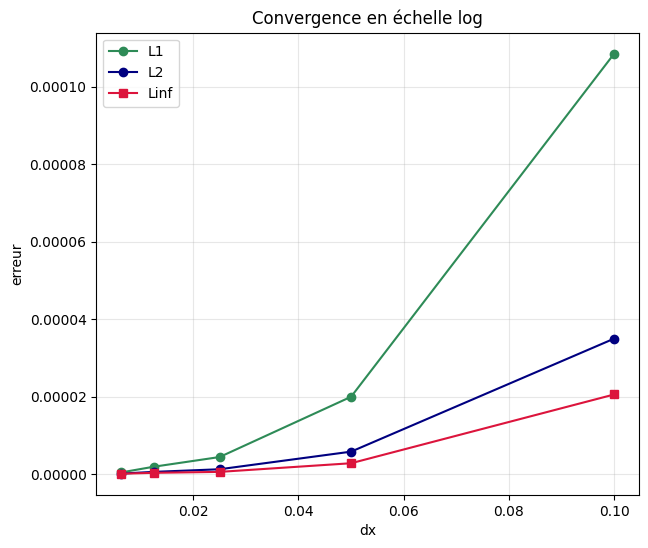

In [9]:
plt.figure(figsize=(7, 6))
plt.plot(dx_list, L1_list, 'o-', label="L1", color='seagreen')
plt.plot(dx_list, L2_list, 'o-', label="L2", color='navy')
plt.plot(dx_list, Linf_list, 's-', label="Linf", color='crimson')
plt.xlabel('dx')
plt.ylabel('erreur')
plt.title(f"Convergence en échelle log")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('convergence_loglog.png', dpi=300, bbox_inches='tight')
plt.show()

Ordre de convergence estimé (L1)   : 1.95
Ordre de convergence estimé (L2)   : 1.98
Ordre de convergence estimé (Linf) : 1.88


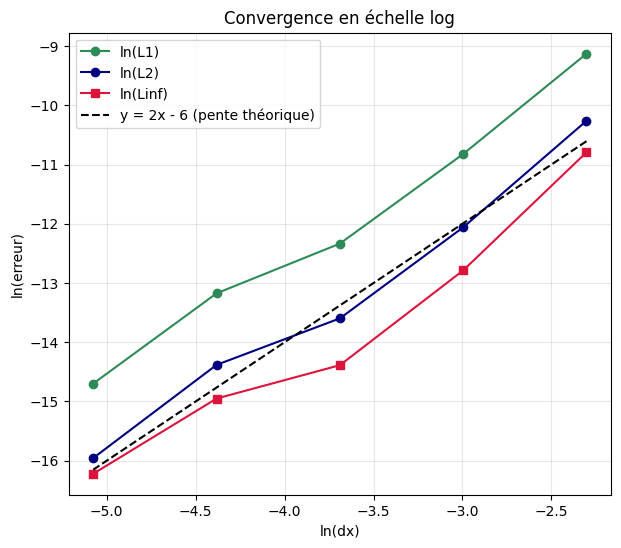

In [10]:
ln_dx = np.log(dx_list)
ln_L1 = np.log(L1_list)
ln_L2 = np.log(L2_list)
ln_Linf = np.log(Linf_list)

# Estimation de la pente (= ordre de convergence) par régression linéaire
pente_L2 = np.polyfit(ln_dx, ln_L2, 1)[0]
pente_Linf = np.polyfit(ln_dx, ln_Linf, 1)[0]
pente_L1 = np.polyfit(ln_dx, ln_L1, 1)[0]
print(f"Ordre de convergence estimé (L1)   : {pente_L1:.2f}")
print(f"Ordre de convergence estimé (L2)   : {pente_L2:.2f}")
print(f"Ordre de convergence estimé (Linf) : {pente_Linf:.2f}")

y_theorique = 2 * ln_dx - 6

plt.figure(figsize=(7, 6))
plt.plot(ln_dx, ln_L1, 'o-', label="ln(L1)", color='seagreen')
plt.plot(ln_dx, ln_L2, 'o-', label="ln(L2)", color='navy')
plt.plot(ln_dx, ln_Linf, 's-', label="ln(Linf)", color='crimson')
plt.plot(ln_dx, y_theorique, 'k--', label="y = 2x - 6 (pente théorique)")
plt.xlabel('ln(dx)')
plt.ylabel('ln(erreur)')
plt.title(f"Convergence en échelle log")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('convergence_log.png', dpi=300, bbox_inches='tight')
plt.show()

### Sénarios possibles 

In [12]:
scenarios = {
    "Diffusion pure (alpha=0)":       dict(D=1.0, alpha=0.0,  sigma=1.0, clf=0.45),
    "Décroissance dominante":         dict(D=0.2, alpha=1.0,  sigma=1.0, clf=0.45),
    "Diffusion rapide":               dict(D=5.0, alpha=0.1,  sigma=1.0, clf=0.45),
    "Front raide":                    dict(D=1.0, alpha=0.1,  sigma=0.3, clf=0.45),
    "Front large":                    dict(D=1.0, alpha=0.1,  sigma=3.0, clf=0.45),
    "Diffusion lente":                dict(D=0.05, alpha=0.1, sigma=1.0, clf=0.45),
    "Décroissance nulle + rapide":    dict(D=5.0, alpha=0.0,  sigma=1.0, clf=0.45),
    "Décroissance forte + lente":     dict(D=0.05, alpha=1.0, sigma=1.0, clf=0.45),
    "CFL limite (0.5)":               dict(D=1.0, alpha=0.1,  sigma=1.0, clf=0.5),
    "Instable (CFL > 0.5)":           dict(D=1.0, alpha=0.1,  sigma=1.0, clf=0.6),
}

resultats = {}

for nom, p in scenarios.items():
    D, alpha, sigma, clf = p["D"], p["alpha"], p["sigma"], p["clf"]

    # Plus besoin de recopier le schéma : on appelle directement la fonction.
    # A, x0, L, T, Nx viennent des paramètres globaux du rapport (inchangés
    # d'un scénario à l'autre), seuls D, alpha, sigma, clf varient ici.
    x_VF, t, U = u_volume_finie(A=A, x0=x0, sigma=sigma, D=D, alpha=alpha,
                                 L=L, T=T, Nx=Nx, clf=clf)

    # dx, dt, r ne sont pas renvoyés par la fonction : on les recalcule
    # à partir du résultat, pour être sûr qu'ils correspondent exactement
    # à CET appel (et pas à une ancienne variable globale périmée).
    dx = x_VF[1] - x_VF[0]
    dt = t[1] - t[0]
    r = D * dt / dx**2

    # Solution exacte avec les MÊMES D, alpha, sigma que le scénario
    U_exacte = np.zeros_like(U)
    for i, ti in enumerate(t):
        U_exacte[i, :] = u_analytique(x_VF, ti, A=A, x0=x0, sigma=sigma, D=D, alpha=alpha)

    resultats[nom] = dict(x=x_VF.copy(), t=t.copy(), U=U.copy(), U_exacte=U_exacte,
                           dx=dx, D=D, alpha=alpha, sigma=sigma, clf=clf, dt=dt, r=r)

espace de temps 0.004500000000000001 espace de position 0.1
espace de temps 0.022500000000000006 espace de position 0.1
espace de temps 0.0009000000000000003 espace de position 0.1
espace de temps 0.004500000000000001 espace de position 0.1
espace de temps 0.004500000000000001 espace de position 0.1
espace de temps 0.09000000000000002 espace de position 0.1
espace de temps 0.0009000000000000003 espace de position 0.1
espace de temps 0.09000000000000002 espace de position 0.1
espace de temps 0.005000000000000001 espace de position 0.1
espace de temps 0.006000000000000001 espace de position 0.1


## Comparaison analytique vs volumes finis — tous les scénarios

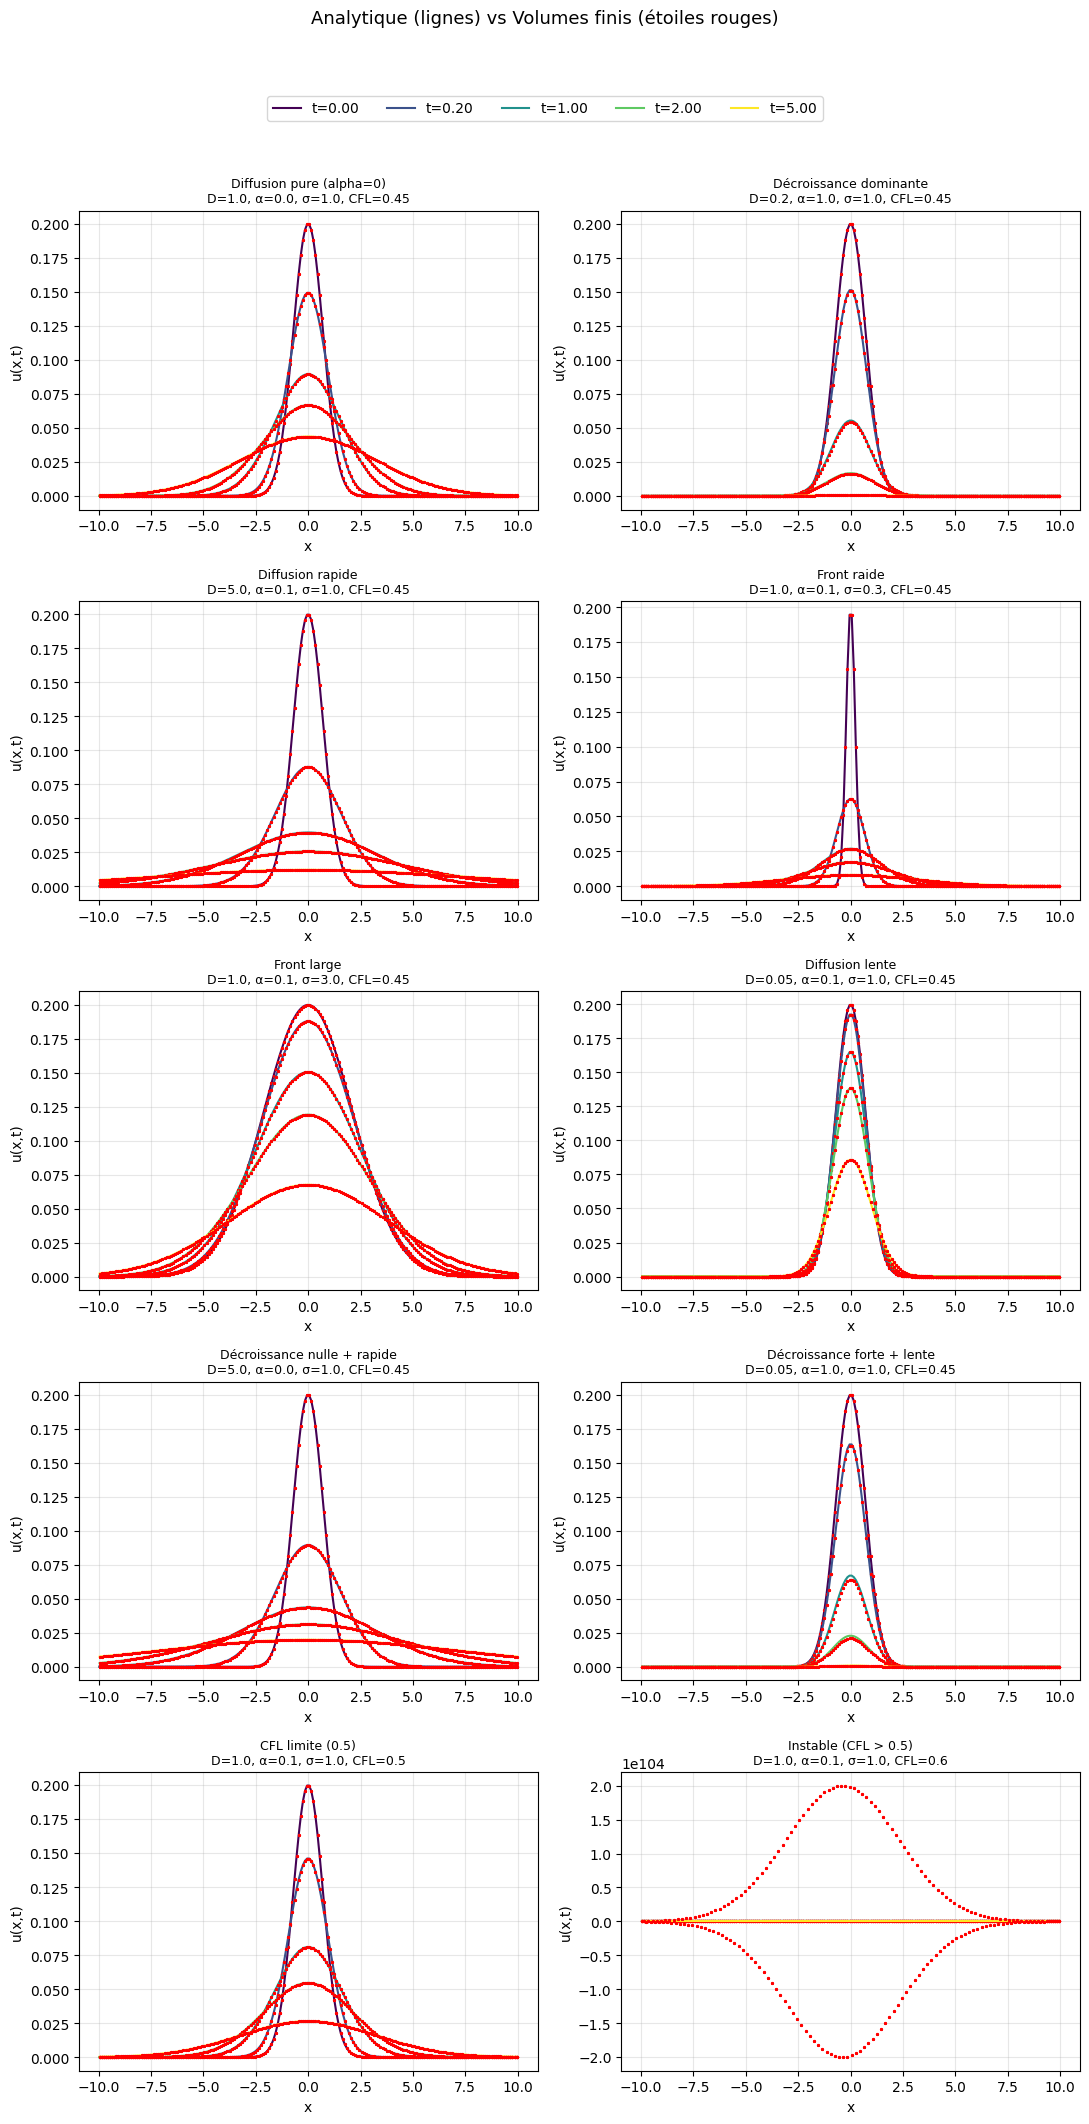

In [13]:
import math

noms = list(resultats.keys())
n_scen = len(noms)
ncols = 2
nrows = math.ceil(n_scen / ncols)

plt.style.use('default')
fig, axes = plt.subplots(nrows, ncols, figsize=(5.5*ncols, 4*nrows))
axes = np.array(axes).reshape(-1)

temps_a_tracer = [1e-4, 0.2, 1, 2, T]
colors = plt.cm.viridis(np.linspace(0, 1, len(temps_a_tracer)))

for k, nom in enumerate(noms):
    ax = axes[k]
    res = resultats[nom]
    x_r, t_r, U_r = res["x"], res["t"], res["U"]
    D_r, alpha_r, sigma_r = res["D"], res["alpha"], res["sigma"]

    for ti, c in zip(temps_a_tracer, colors):
        idx = np.argmin(np.abs(t_r - ti)) 
        U_exacte = res["U_exacte"] 
        ax.plot(x_r, U_exacte[idx], color=c, linewidth=1.5, label=f"t={ti:.2f}")
        ax.plot(x_r, U_r[idx, :], color="red", marker='*', markersize=2,
                linestyle='none')

    ax.set_title(f"{nom}\nD={D_r}, α={alpha_r}, σ={sigma_r}, CFL={res['clf']}", fontsize=9)
    ax.set_xlabel('x')
    ax.set_ylabel('u(x,t)')
    ax.grid(True, alpha=0.3)

# Cacher les axes vides s'il y en a
for k in range(n_scen, len(axes)):
    axes[k].axis('off')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=len(temps_a_tracer), bbox_to_anchor=(0.5, 1.02))
fig.suptitle("Analytique (lignes) vs Volumes finis (étoiles rouges)", y=1.06, fontsize=13)
plt.tight_layout()
plt.savefig('diffusion_scenarios.png', dpi=300, bbox_inches='tight')
plt.show()


## Tableau récapitulatif de tous les scénarios

In [14]:
print(f"{'Scénario':30s} {'D':>6s} {'alpha':>7s} {'sigma':>7s} {'CFL':>6s} {'Nt':>7s} ")
print("-" * 100)
for nom in noms:
    res = resultats[nom]
    
    print(f"{nom:30s} {res['D']:6.2f} {res['alpha']:7.2f} {res['sigma']:7.2f} "
          f"{res['clf']:6.2f} {len(res['t']):7d} ")


Scénario                            D   alpha   sigma    CFL      Nt 
----------------------------------------------------------------------------------------------------
Diffusion pure (alpha=0)         1.00    0.00    1.00   0.45    1112 
Décroissance dominante           0.20    1.00    1.00   0.45     223 
Diffusion rapide                 5.00    0.10    1.00   0.45    5556 
Front raide                      1.00    0.10    0.30   0.45    1112 
Front large                      1.00    0.10    3.00   0.45    1112 
Diffusion lente                  0.05    0.10    1.00   0.45      56 
Décroissance nulle + rapide      5.00    0.00    1.00   0.45    5556 
Décroissance forte + lente       0.05    1.00    1.00   0.45      56 
CFL limite (0.5)                 1.00    0.10    1.00   0.50    1000 
Instable (CFL > 0.5)             1.00    0.10    1.00   0.60     834 


# Partie Deep Learning

### Génération de dataset à partir de solution exacte

In [9]:
# Paramètres du choc — remise à zéro après la boucle sur les scénarios,
# qui a réassigné A, x0, sigma, D, alpha, clf en variables globales.
A = 0.2
x0 = 0.0
sigma = 1.0
D = 1.0
alpha = 0.1
L = 10
T = 5
print(D, alpha, sigma,A, x0, clf, Nt,T)

1.0 0.1 1.0 0.2 0.0 0.45 100 5


In [10]:
# Génération d'un jeu de données avec sur-échantillonnage renforcé
# autour du choc initial (t proche de 0, x proche de x0)

np.random.seed(0)

N_total = 7000
N_focus = int(0.3 * N_total)      # 30% des points concentrés près du choc initial
N_uniform = N_total - N_focus

# Partie 1 : échantillonnage uniforme (identique à avant)
t_unif = np.random.uniform(0, T, N_uniform)
x_unif = np.random.uniform(-L, L, N_uniform)

# Partie 2 : échantillonnage concentré près de (x0, t=0)
t_focus = np.clip(np.random.exponential(scale=0.3, size=N_focus), 0, T)
x_focus = np.clip(np.random.normal(loc=x0, scale=sigma, size=N_focus), -L, L)

t_data2 = np.concatenate([t_unif, t_focus])
x_data2 = np.concatenate([x_unif, x_focus])
u_data2 = u_analytique(x_data2, t_data2, A, x0, sigma, D, alpha)

df = pd.DataFrame({'t': t_data2, 'x': x_data2, 'u_exacte': u_data2})
df.to_csv('dataset_diffusion.csv', index=False)

print(f"Total points : {len(df)}  (dont {N_focus} concentrés près du choc initial)")

Total points : 7000  (dont 2100 concentrés près du choc initial)


In [11]:
print("les lignes du DataFrame :")
print(df.head())
print("Résumé statistique du DataFrame :")
df.describe()

les lignes du DataFrame :
          t         x  u_exacte
0  2.744068  5.179377  0.004676
1  3.575947  6.348490  0.002568
2  3.013817 -4.355971  0.009573
3  2.724416 -4.896879  0.005884
4  2.118274 -1.172848  0.045470
Résumé statistique du DataFrame :


,t,x,u_exacte
count,7000.000000,7000.000000,7.000000e+03
mean,1.830358,-0.076787,3.919684e-02
std,1.580687,4.878460,4.925343e-02
min,0.000062,-9.996992,6.031054e-41
25%,0.332043,-2.815086,6.930451e-04
50%,1.448988,-0.044515,1.719647e-02
75%,3.180146,2.732844,6.385298e-02
max,4.999820,9.999559,1.978473e-01


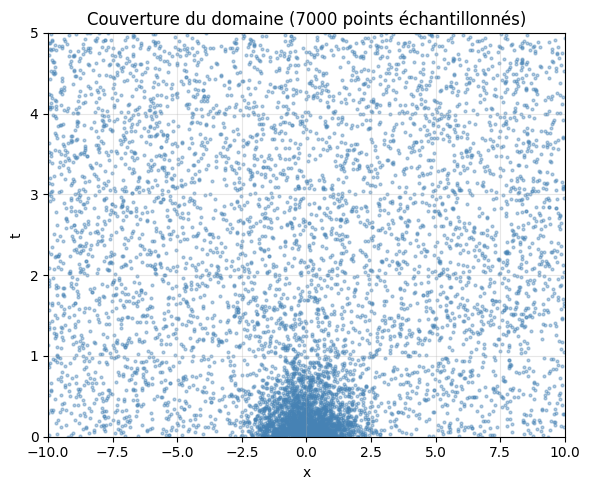

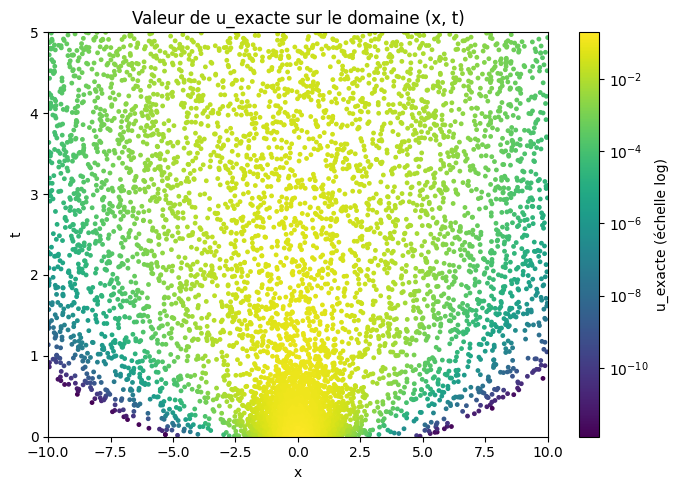

In [12]:
# ---------------------------------------------------------------------
# Graphe 1 : couverture du domaine (x, t)
# ---------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(df['x'], df['t'], s=4, alpha=0.4, color='steelblue')
ax.set_xlabel('x')
ax.set_ylabel('t')
ax.set_title(f"Couverture du domaine ({len(df)} points échantillonnés)")
ax.set_xlim(-L, L)
ax.set_ylim(0, T)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('couverture_domaine.png', dpi=300, bbox_inches='tight')
plt.show()

# ---------------------------------------------------------------------
# Graphe 2 : valeur de u_exacte (échelle log, car u varie sur ~40 ordres
# de grandeur entre le centre du choc et les zones lointaines/tardives)
# ---------------------------------------------------------------------
from matplotlib.colors import LogNorm

fig, ax = plt.subplots(figsize=(7, 5))

# LogNorm exige des valeurs strictement positives : on écarte les valeurs
# numériquement nulles (en dessous d'un seuil) qui feraient planter LogNorm
mask = df['u_exacte'] > 1e-12

sc = ax.scatter(df['x'][mask], df['t'][mask], c=df['u_exacte'][mask], s=6,
                 cmap='viridis',
                 norm=LogNorm(vmin=df['u_exacte'][mask].min(),
                               vmax=df['u_exacte'][mask].max()))
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('u_exacte (échelle log)')
ax.set_xlabel('x')
ax.set_ylabel('t')
ax.set_title("Valeur de u_exacte sur le domaine (x, t)")
ax.set_xlim(-L, L)
ax.set_ylim(0, T)
plt.tight_layout()
plt.savefig('valeur_u_exacte.png', dpi=300, bbox_inches='tight')
plt.show()

### Réseau de neurone 

In [13]:
from sklearn.model_selection import train_test_split
df = pd.read_csv('dataset_diffusion.csv')
# Étape 1 : séparer train (70%) et "temp" (30%)
df_train, df_temp = train_test_split(df, test_size=0.3, random_state=42)

# Étape 2 : séparer temp en validation (15%) et test (15%)
df_val, df_test = train_test_split(df_temp, test_size=0.5, random_state=42)

print(f"Train : {len(df_train)} points")
print(f"Val   : {len(df_val)} points")
print(f"Test  : {len(df_test)} points")

Train : 4900 points
Val   : 1050 points
Test  : 1050 points


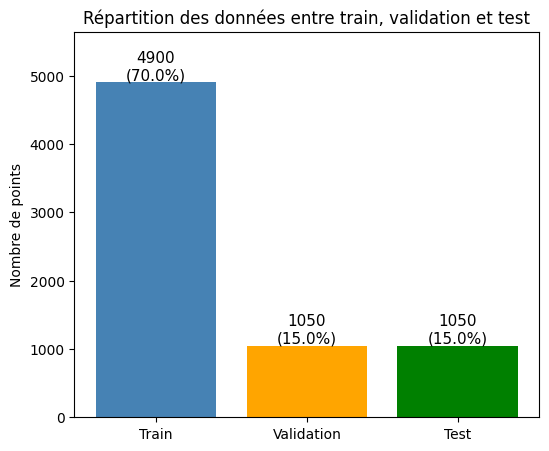

In [14]:
labels = ['Train', 'Validation', 'Test']
counts = [len(df_train), len(df_val), len(df_test)]
total = sum(counts)

plt.figure(figsize=(6, 5))
bars = plt.bar(labels, counts, color=['steelblue', 'orange', 'green'])

for bar, count in zip(bars, counts):
    pourcentage = 100 * count / total
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
              f"{count}\n({pourcentage:.1f}%)",
              ha='center', va='bottom', fontsize=11)

plt.ylabel('Nombre de points')
plt.title("Répartition des données entre train, validation et test")
plt.ylim(0, max(counts) * 1.15)  # un peu de marge en haut pour le texte
plt.savefig('repartition_donnees.png', dpi=300, bbox_inches='tight')
plt.show()

In [15]:
eps = 1e-12
u_log_train = np.log(df_train['u_exacte'].values + eps)
u_log_val   = np.log(df_val['u_exacte'].values + eps)
u_log_test  = np.log(df_test['u_exacte'].values + eps)

x_mean, x_std = df_train['x'].mean(), df_train['x'].std()
t_mean, t_std = df_train['t'].mean(), df_train['t'].std()
u_mean, u_std = u_log_train.mean(), u_log_train.std()

def normalize(df_subset, u_log):
    x_norm = (df_subset['x'].values - x_mean) / x_std
    t_norm = (df_subset['t'].values - t_mean) / t_std
    u_norm = (u_log - u_mean) / u_std
    X = torch.tensor(np.column_stack([x_norm, t_norm]), dtype=torch.float32)
    y = torch.tensor(u_norm, dtype=torch.float32).view(-1, 1)
    return X, y

X_train, y_train = normalize(df_train, u_log_train)
X_val,   y_val   = normalize(df_val,   u_log_val)
X_test,  y_test  = normalize(df_test,  u_log_test)


In [16]:
print(X_train.shape, y_train.shape)
print(X_train.mean(dim=0), X_train.std(dim=0))

torch.Size([4900, 2]) torch.Size([4900, 1])
tensor([ 3.8925e-10, -5.8388e-10]) tensor([1., 1.])


### Comparaison des modéles possibles

In [17]:
def make_mlp(n_layers, hidden, act_fn):
    layers = [nn.Linear(2, hidden), act_fn()]
    for _ in range(n_layers - 1):
        layers += [nn.Linear(hidden, hidden), act_fn()]
    layers += [nn.Linear(hidden, 1)]
    return nn.Sequential(*layers)

def count_params(m):
    return sum(p.numel() for p in m.parameters())

def train_quick(model, epochs=400, lr=1e-3):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    crit = nn.MSELoss()
    best_val = float('inf')
    for ep in range(epochs):
        model.train(); opt.zero_grad()
        loss = crit(model(X_train), y_train)
        loss.backward(); opt.step()
        model.eval()
        with torch.no_grad():
            vl = crit(model(X_val), y_val).item()
        if vl < best_val:
            best_val = vl
    return best_val, loss.item()

configs = [
    ("1x16, tanh", 1, 16, nn.Tanh),
    ("1x32, tanh", 1, 32, nn.Tanh),
    ("2x32, tanh", 2, 32, nn.Tanh),
    ("3x32, tanh", 3, 32, nn.Tanh),
    ("4x32, tanh", 4, 32, nn.Tanh),
    ("3x64, tanh", 3, 64, nn.Tanh),
    ("3x32, relu", 3, 32, nn.ReLU),
]

resultats_archi = []
print(f"{'config':15s} {'#params':>8s} {'train_mse':>12s} {'val_mse':>12s}")
for name, nl, h, act in configs:
    torch.manual_seed(0)
    m = make_mlp(nl, h, act)
    n_params = count_params(m)
    val_mse, train_mse = train_quick(m, epochs=400)
    resultats_archi.append((name, n_params, train_mse, val_mse))
    print(f"{name:15s} {n_params:8d} {train_mse:12.6f} {val_mse:12.6f}")

df_archi = pd.DataFrame(resultats_archi, columns=['config', 'n_params', 'train_mse', 'val_mse'])
df_archi.to_csv('comparaison_architectures.csv', index=False)

config           #params    train_mse      val_mse
1x16, tanh            65     0.246751     0.201504
1x32, tanh           129     0.173149     0.139552
2x32, tanh          1185     0.023519     0.016696
3x32, tanh          2241     0.012766     0.008346
4x32, tanh          3297     0.009524     0.006089
3x64, tanh          8577     0.009715     0.006422
3x32, relu          2241     0.007565     0.005171


In [22]:


class MLP(nn.Module):
    def __init__(self, hidden_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x):
        return self.net(x)

# Modèle ET optimiseur recréés ensemble, dans la même cellule
model = MLP(hidden_dim=32)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Vérification de synchronisation
model_param_ids = set(id(p) for p in model.parameters())
optim_param_ids = set(id(p) for group in optimizer.param_groups for p in group['params'])
print("Modèle et optimiseur synchronisés :", model_param_ids == optim_param_ids)

Modèle et optimiseur synchronisés : True


In [23]:
n_epochs = 1790
train_losses, val_losses = [], []
best_val_loss = float('inf')
best_model_state = None

for epoch in range(n_epochs):
    model.train()
    optimizer.zero_grad()
    y_pred = model(X_train)
    loss = criterion(y_pred, y_train)
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        y_val_pred = model(X_val)
        val_loss = criterion(y_val_pred, y_val)

    train_losses.append(loss.item())
    val_losses.append(val_loss.item())

    if val_loss.item() < best_val_loss:
        best_val_loss = val_loss.item()
        best_model_state = model.state_dict()

    if epoch % 200 == 0:
        print(f"Epoch {epoch:4d} | Train loss: {loss.item():.6f} | Val loss: {val_loss.item():.6f}")

model.load_state_dict(best_model_state)
print(f"Meilleure val loss : {best_val_loss:.6f}")

Epoch    0 | Train loss: 1.014677 | Val loss: 0.896069
Epoch  200 | Train loss: 0.044264 | Val loss: 0.032961
Epoch  400 | Train loss: 0.014090 | Val loss: 0.008908
Epoch  600 | Train loss: 0.008498 | Val loss: 0.005323
Epoch  800 | Train loss: 0.005364 | Val loss: 0.003434
Epoch 1000 | Train loss: 0.003422 | Val loss: 0.002360
Epoch 1200 | Train loss: 0.002233 | Val loss: 0.001660
Epoch 1400 | Train loss: 0.001476 | Val loss: 0.001152
Epoch 1600 | Train loss: 0.000987 | Val loss: 0.000797
Meilleure val loss : 0.000565


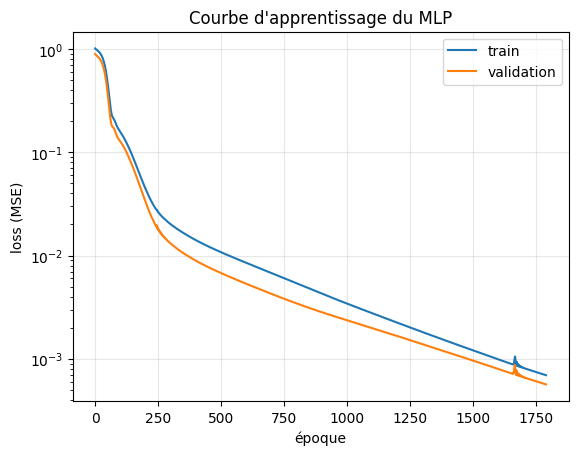

In [24]:
plt.plot(train_losses, label='train')
plt.plot(val_losses, label='validation')
plt.yscale('log')
plt.xlabel('époque')
plt.ylabel('loss (MSE)')
plt.legend(); plt.grid(True, alpha=0.3)
plt.title("Courbe d'apprentissage du MLP")
plt.savefig('courbe_apprentissage_MLP.png', dpi=300, bbox_inches='tight')
plt.show()

In [25]:
model.eval()
with torch.no_grad():
    y_pred_norm = model(X_test).numpy().flatten()

u_log_pred = y_pred_norm * u_std + u_mean
u_pred = np.exp(u_log_pred) - eps
u_exacte_test = np.exp(u_log_test) - eps

diff = u_pred - u_exacte_test
MSE_mlp  = np.mean(diff**2)
L2_mlp   = np.sqrt(MSE_mlp)          # RMSE
MAE_mlp  = np.mean(np.abs(diff))
Linf_mlp = np.max(np.abs(diff))

print(f"Erreur MLP (test) | MSE={MSE_mlp:.3e} | L2(RMSE)={L2_mlp:.3e} | MAE={MAE_mlp:.3e} | L∞={Linf_mlp:.3e}")

Erreur MLP (test) | MSE=8.050e-06 | L2(RMSE)=2.837e-03 | MAE=1.263e-03 | L∞=2.553e-02


espace de temps 0.004500000000000001 espace de position 0.1


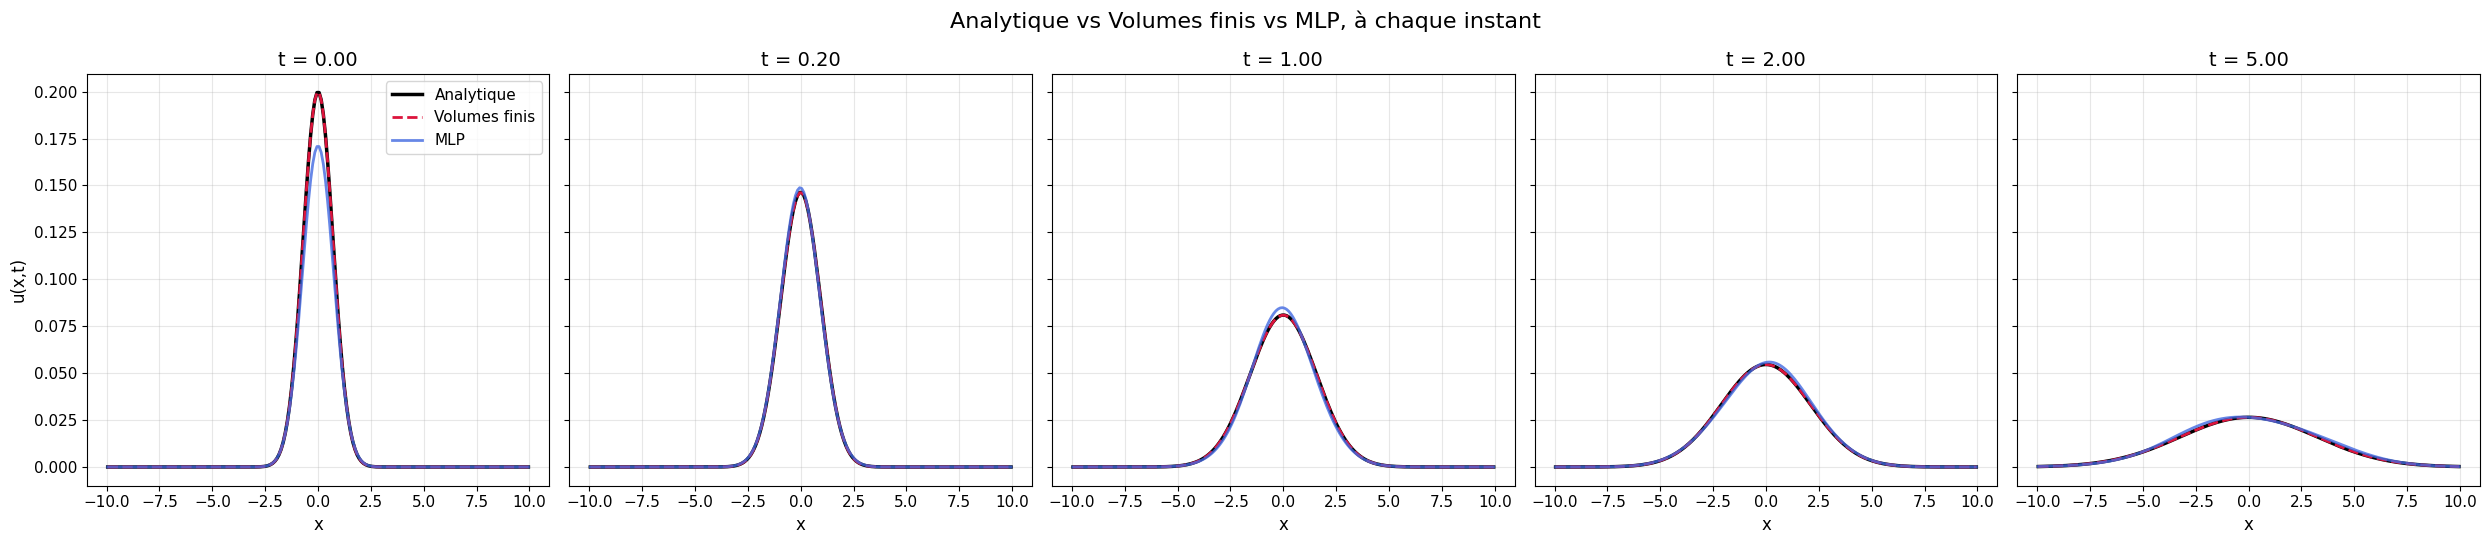

Erreur L2 max — Volumes finis : 0.000182
Erreur L2 max — MLP           : 0.029155


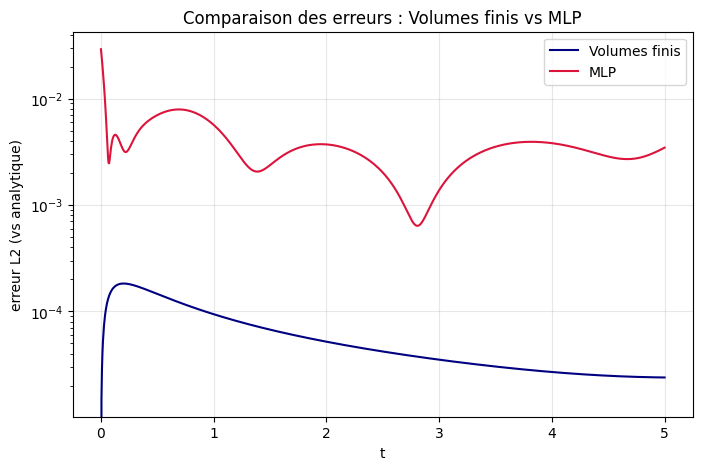

In [26]:
# --- Construire une grille régulière (x, t) pour comparer les trois solutions ---
x_grille, t_grille, U_vf_grille = u_volume_finie(A=A, x0=x0, sigma=sigma, D=D, alpha=alpha, L=L, T=T, Nx=Nx)

# --- Prédictions du MLP sur toute la grille ---
X_mesh, T_mesh = np.meshgrid(x_grille, t_grille)
x_flat = X_mesh.ravel()
t_flat = T_mesh.ravel()

x_flat_norm = (x_flat - x_mean) / x_std
t_flat_norm = (t_flat - t_mean) / t_std
entre_grille = torch.tensor(np.column_stack([x_flat_norm, t_flat_norm]), dtype=torch.float32)

model.eval()
with torch.no_grad():
    sortie_norm = model(entre_grille)

# Dénormalisation (inverse exact de la transformation log + eps utilisée à l'entraînement)
u_log_pred = sortie_norm.numpy().flatten() * u_std + u_mean
U_mlp_grille = (np.exp(u_log_pred) - eps).reshape(X_mesh.shape)

# --- Graphe de comparaison à trois ---
temps_a_tracer = [1e-4, 0.2, 1, 2, T]

fig, axes = plt.subplots(1, len(temps_a_tracer), figsize=(5*len(temps_a_tracer), 5.5), sharey=True)

for ax, ti in zip(axes, temps_a_tracer):
    idx = np.argmin(np.abs(t_grille - ti))
    U_exacte_ti = u_analytique(x_grille, t_grille[idx], A, x0, sigma, D, alpha)

    ax.plot(x_grille, U_exacte_ti, color='black', linewidth=2.5, label="Analytique")
    ax.plot(x_grille, U_vf_grille[idx, :], color='crimson', linestyle='--', linewidth=2, label="Volumes finis")
    ax.plot(x_grille, U_mlp_grille[idx, :], color='royalblue', linewidth=2, alpha=0.8, label="MLP")

    ax.set_title(f"t = {ti:.2f}", fontsize=14)
    ax.set_xlabel('x', fontsize=12)
    ax.tick_params(labelsize=11)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('u(x,t)', fontsize=12)
axes[0].legend(fontsize=11)
plt.suptitle("Analytique vs Volumes finis vs MLP, à chaque instant", fontsize=16)
plt.tight_layout()
plt.savefig('comparaison_solutions.png', dpi=300, bbox_inches='tight')
plt.show()

# --- Erreurs globales des deux méthodes par rapport à l'analytique, sur la grille ---
U_exacte_grille = np.array([u_analytique(x_grille, ti, A, x0, sigma, D, alpha) for ti in t_grille])
dx_grille = x_grille[1] - x_grille[0]

erreur_vf = U_vf_grille - U_exacte_grille
erreur_mlp = U_mlp_grille - U_exacte_grille

L2_vf = np.sqrt(dx_grille * np.sum(erreur_vf**2, axis=1))
L2_mlp = np.sqrt(dx_grille * np.sum(erreur_mlp**2, axis=1))

print(f"Erreur L2 max — Volumes finis : {L2_vf.max():.6f}")
print(f"Erreur L2 max — MLP           : {L2_mlp.max():.6f}")

plt.figure(figsize=(8, 5))
plt.plot(t_grille, L2_vf, label="Volumes finis", color='navy')
plt.plot(t_grille, L2_mlp, label="MLP", color='crimson')
plt.xlabel('t')
plt.ylabel('erreur L2 (vs analytique)')
plt.yscale('log')
plt.legend()
plt.grid(True, alpha=0.3)
plt.title("Comparaison des erreurs : Volumes finis vs MLP")
plt.savefig('comparaison_erreurs_L2.png', dpi=300, bbox_inches='tight')
plt.show()

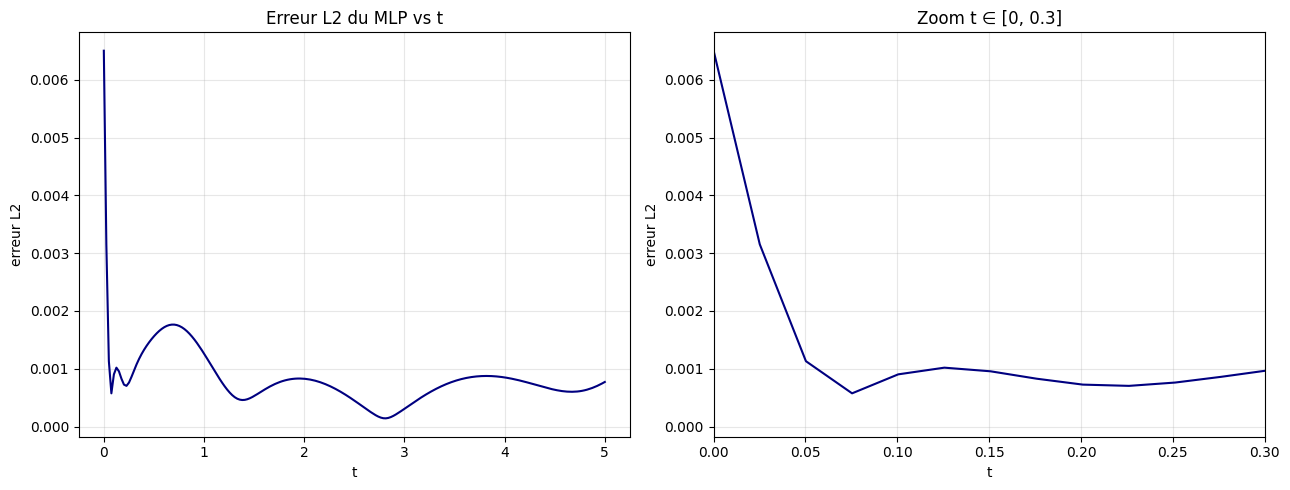

In [27]:
# Erreur du MLP en fonction de t, avec zoom sur le choc initial
t_test_vals = np.linspace(0, T, 200)
x_grille_err = np.linspace(-L, L, Nx)

erreurs_L2_t, erreurs_Linf_t = [], []
for ti in t_test_vals:
    x_n = (x_grille_err - x_mean) / x_std
    t_n = (np.full_like(x_grille_err, ti) - t_mean) / t_std
    Xg = torch.tensor(np.column_stack([x_n, t_n]), dtype=torch.float32)
    with torch.no_grad():
        u_log_g = model(Xg).numpy().flatten() * u_std + u_mean
    u_pred_g = np.exp(u_log_g) - eps
    u_exacte_g = u_analytique(x_grille_err, ti, A, x0, sigma, D, alpha)
    diff = u_pred_g - u_exacte_g
    erreurs_L2_t.append(np.sqrt(np.mean(diff**2)))
    erreurs_Linf_t.append(np.max(np.abs(diff)))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(t_test_vals, erreurs_L2_t, color='navy')
axes[0].set_title("Erreur L2 du MLP vs t")
axes[1].plot(t_test_vals, erreurs_L2_t, color='navy')
axes[1].set_xlim(0, 0.3)  # zoom sur le choc initial
axes[1].set_title("Zoom t ∈ [0, 0.3]")
for ax in axes:
    ax.set_xlabel('t'); ax.set_ylabel('erreur L2'); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('erreur_MLP_vs_t.png', dpi=300, bbox_inches='tight')
plt.show()

### Étude comparative de l'architecture (profondeur, largeur, activation)

espace de temps 0.004500000000000001 espace de position 0.1


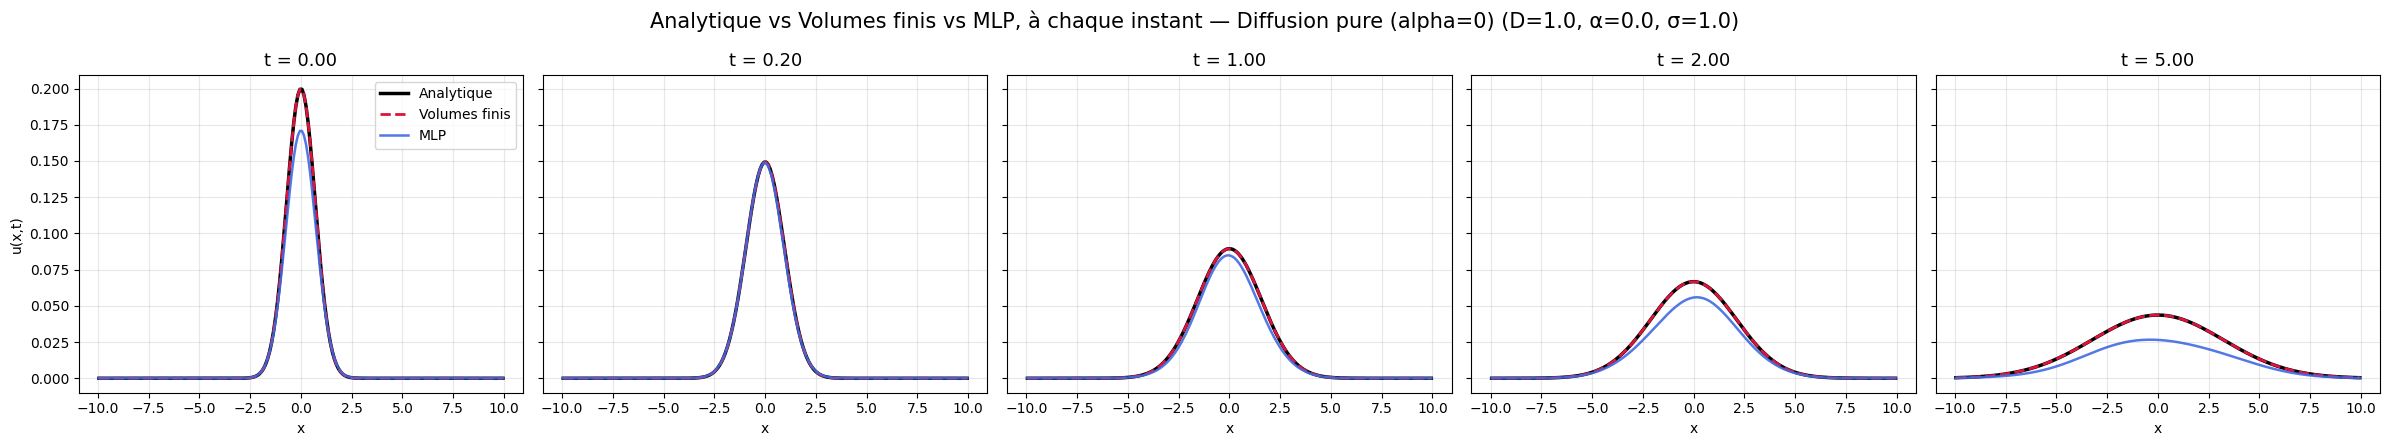

espace de temps 0.022500000000000006 espace de position 0.1


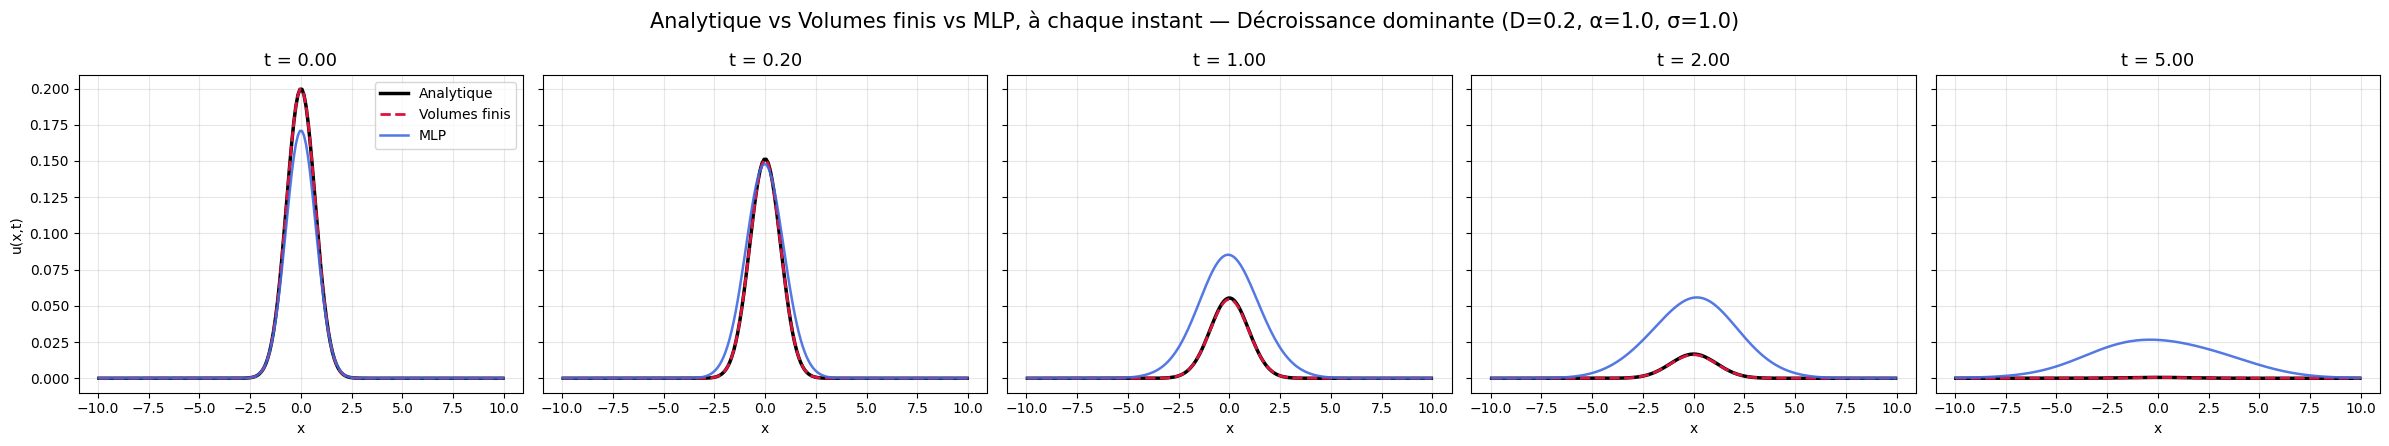

espace de temps 0.0009000000000000003 espace de position 0.1


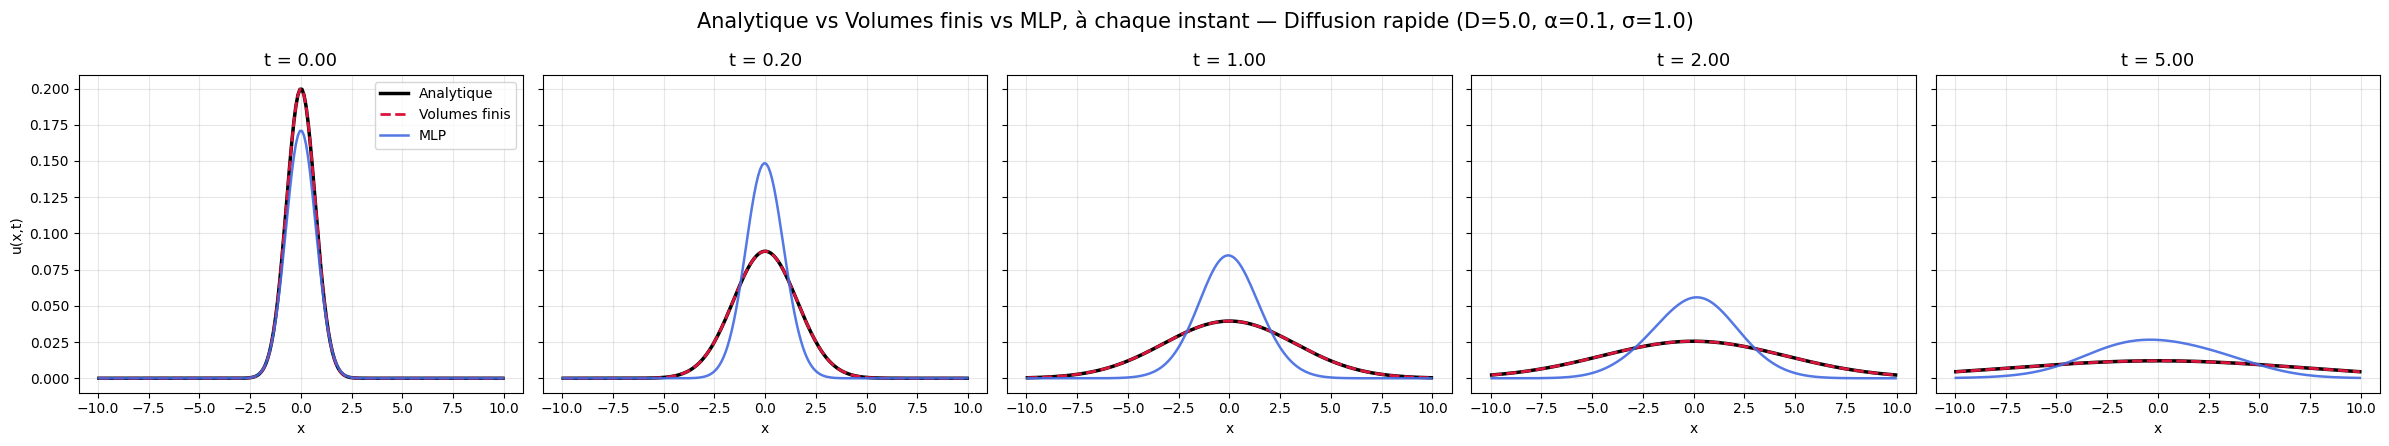

espace de temps 0.004500000000000001 espace de position 0.1


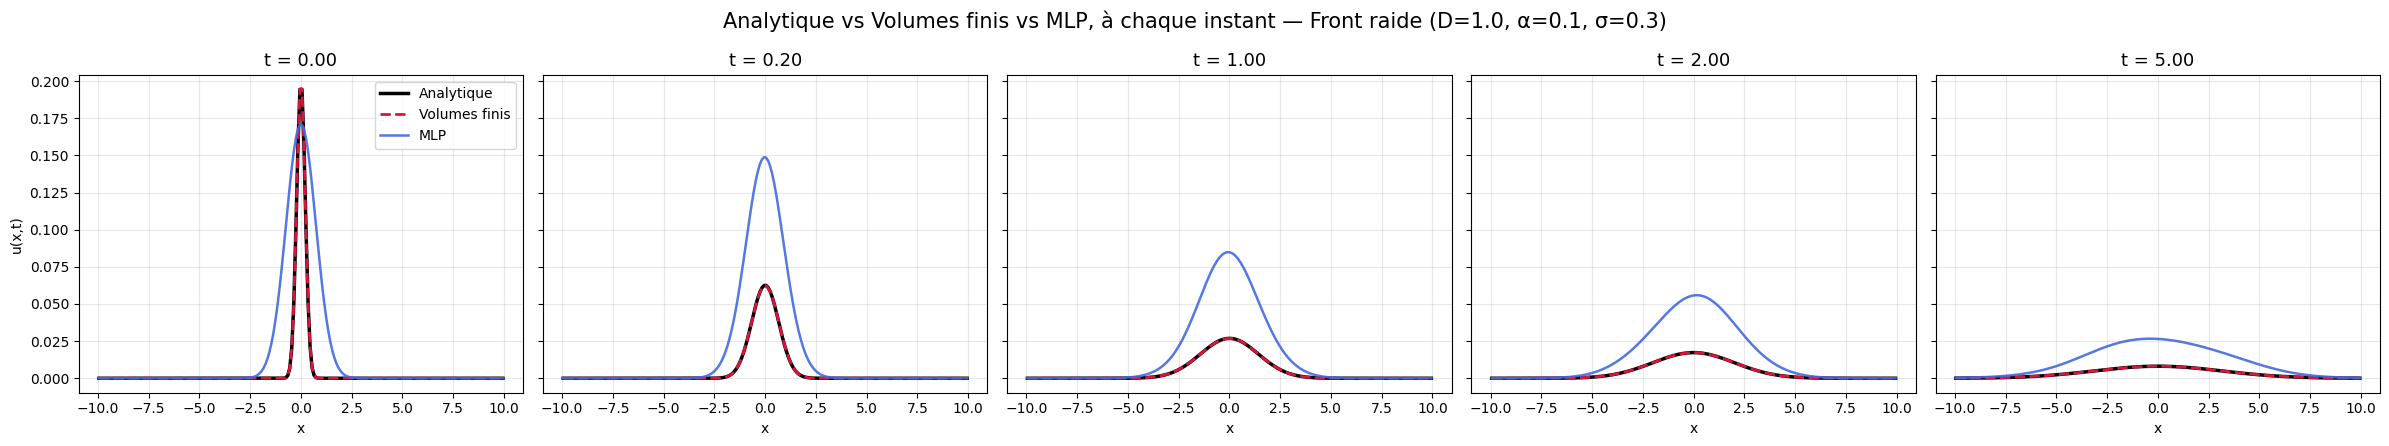

espace de temps 0.004500000000000001 espace de position 0.1


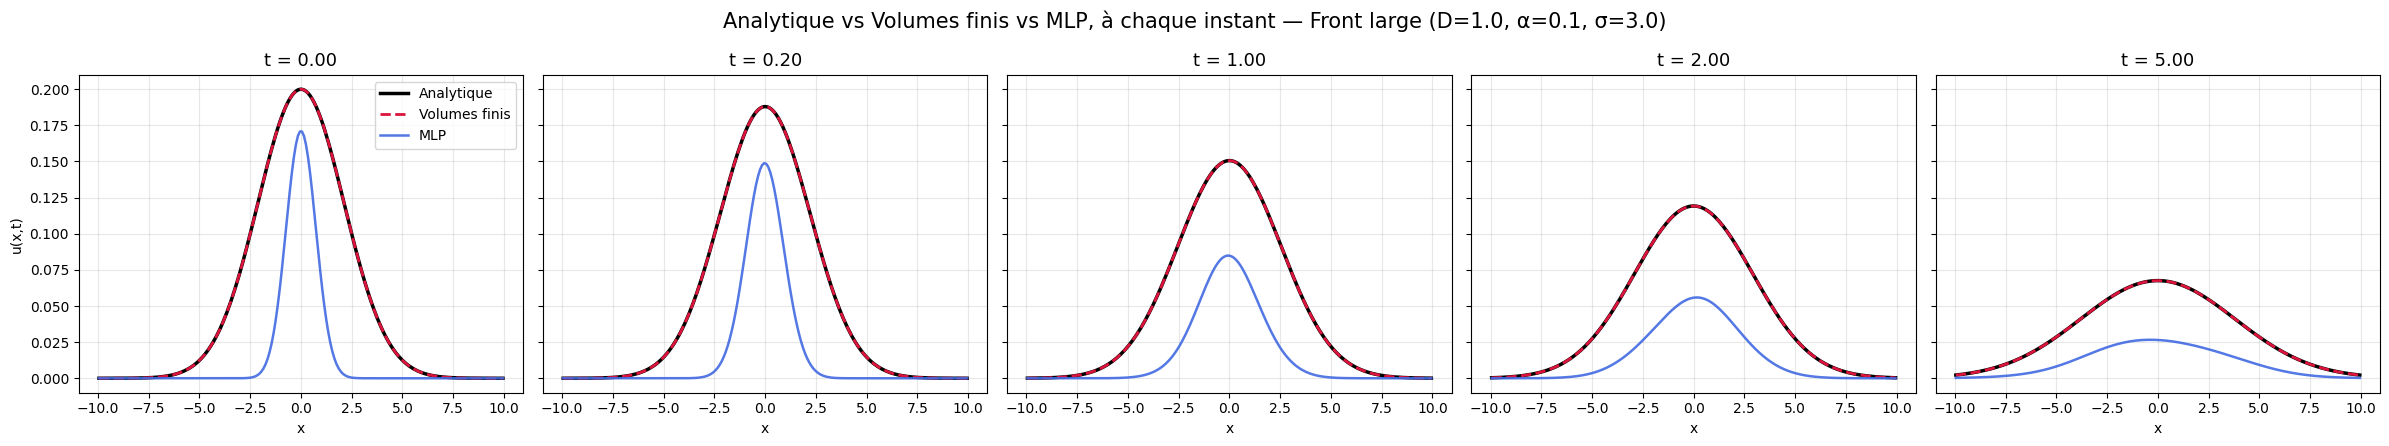

espace de temps 0.09000000000000002 espace de position 0.1


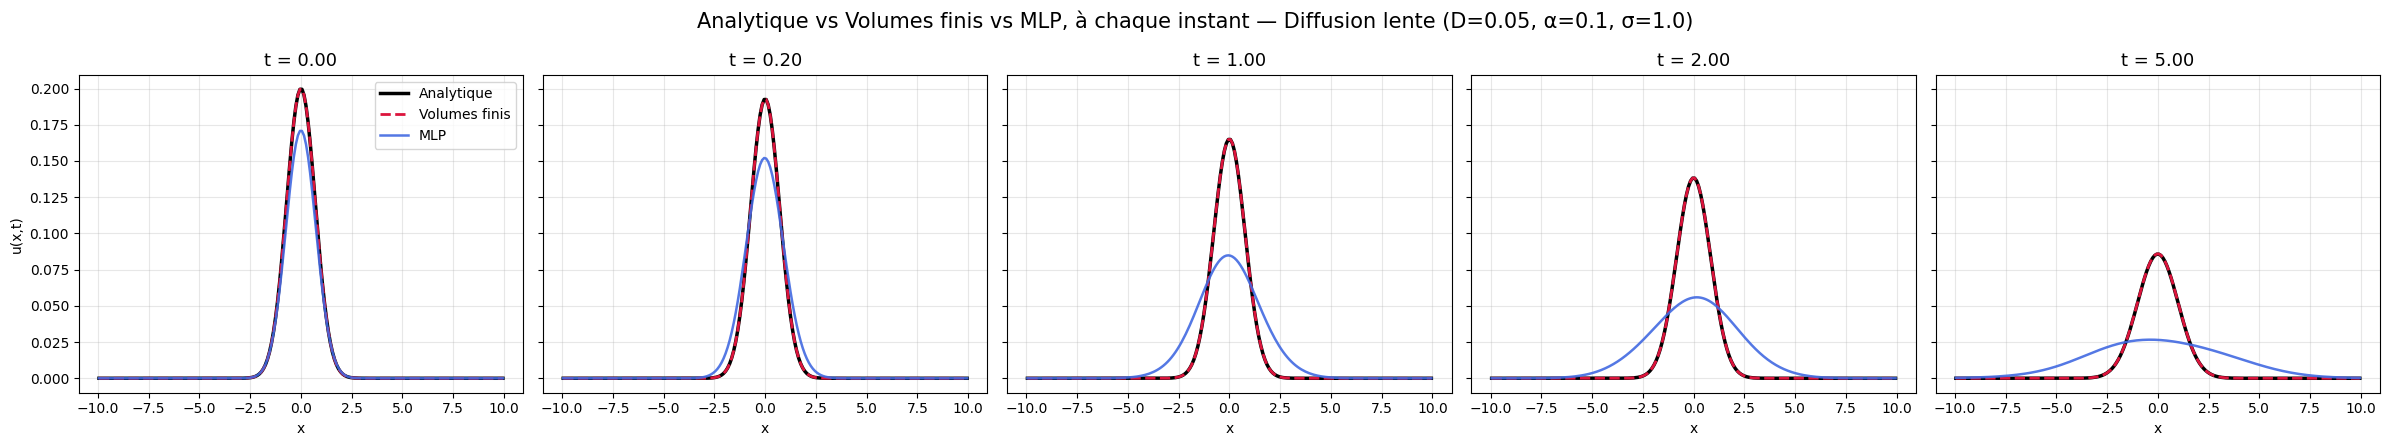

espace de temps 0.0009000000000000003 espace de position 0.1


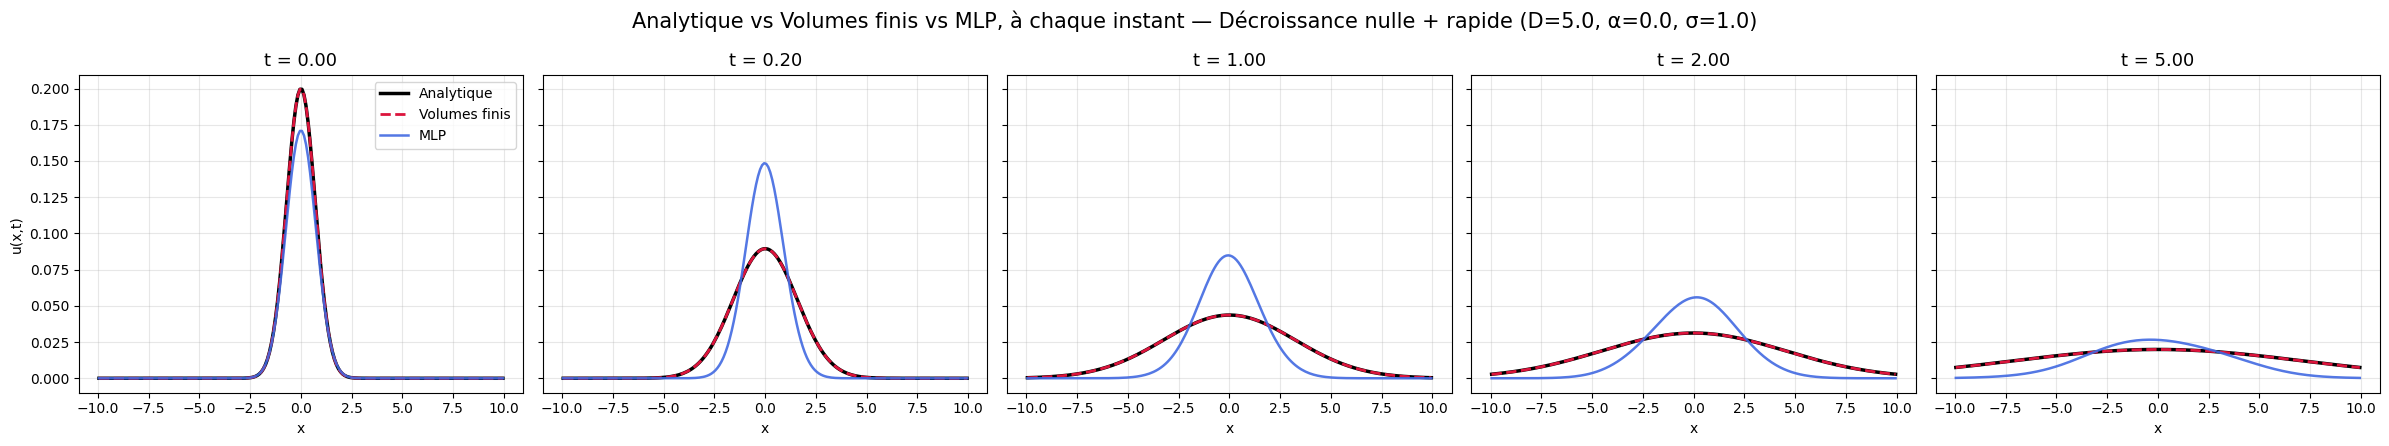

espace de temps 0.09000000000000002 espace de position 0.1


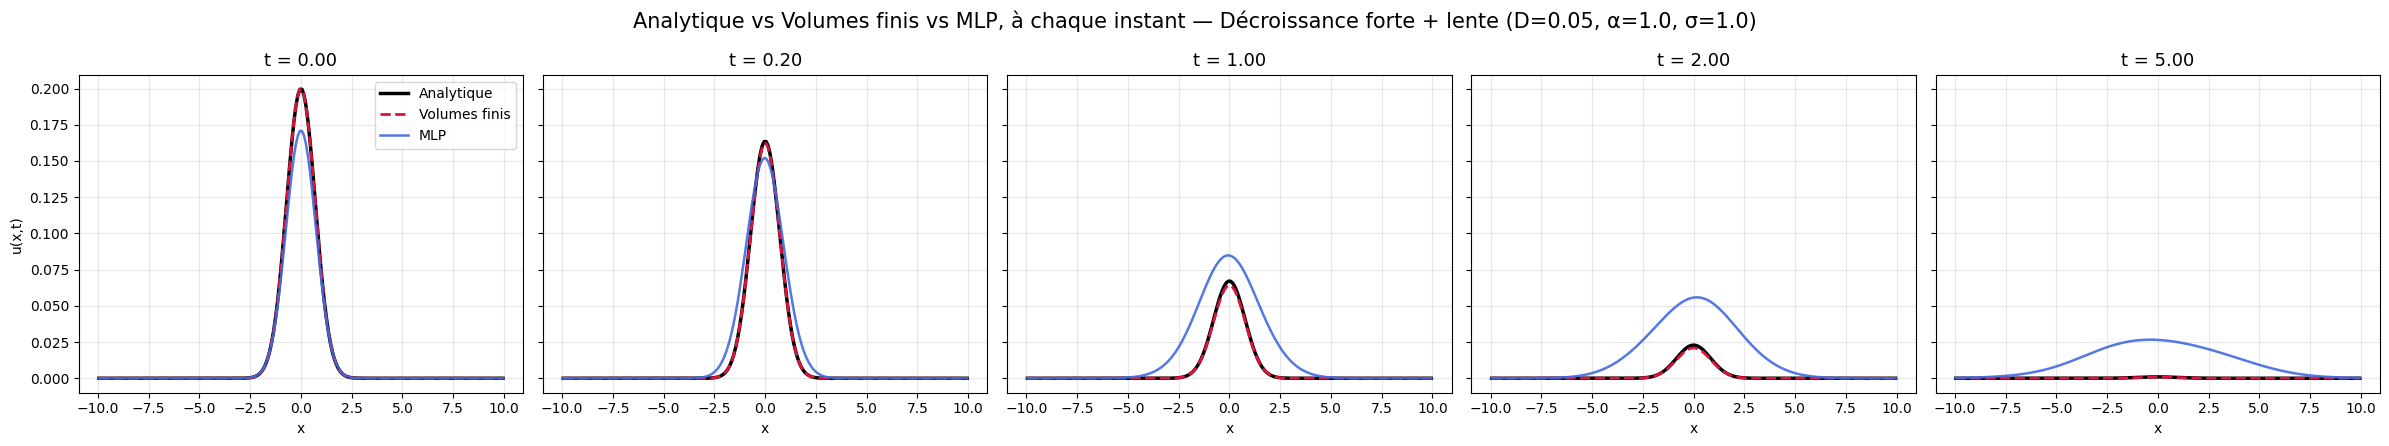

espace de temps 0.005000000000000001 espace de position 0.1


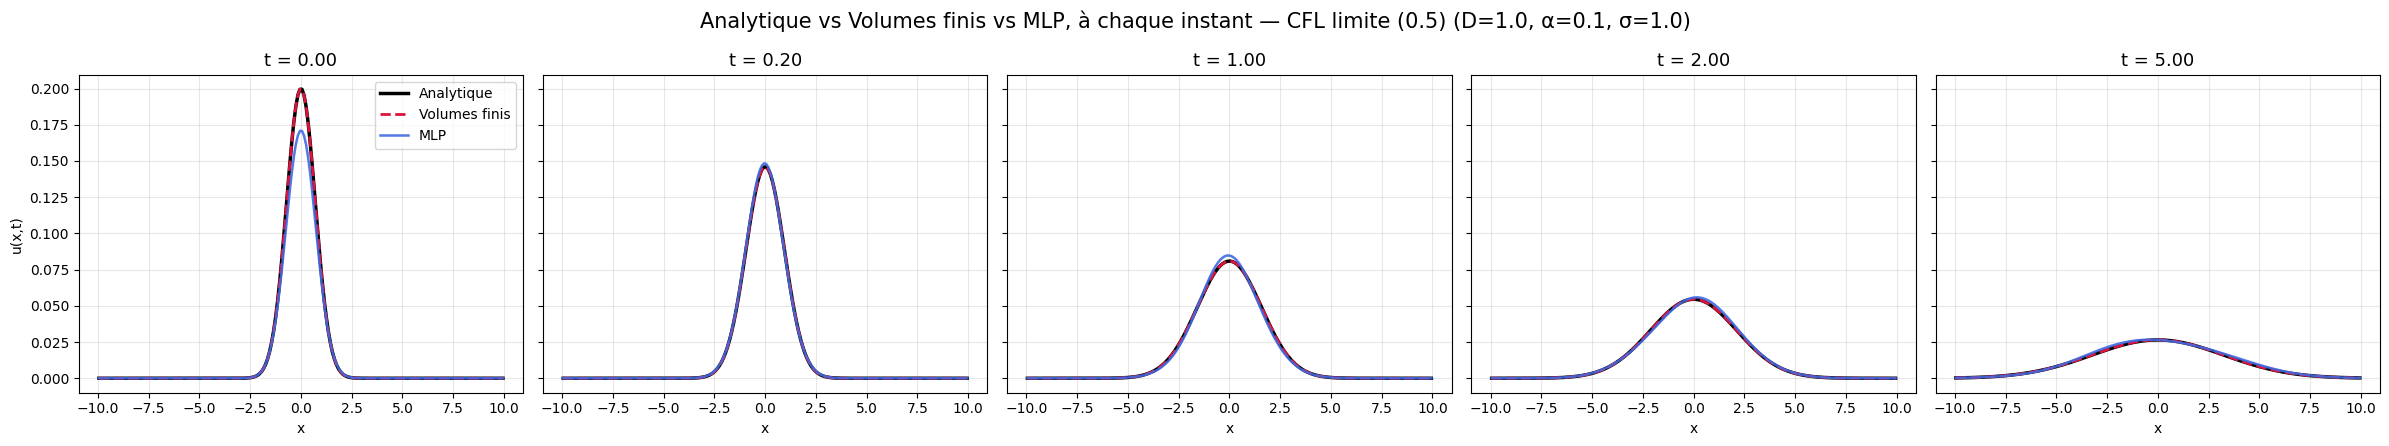

espace de temps 0.006000000000000001 espace de position 0.1


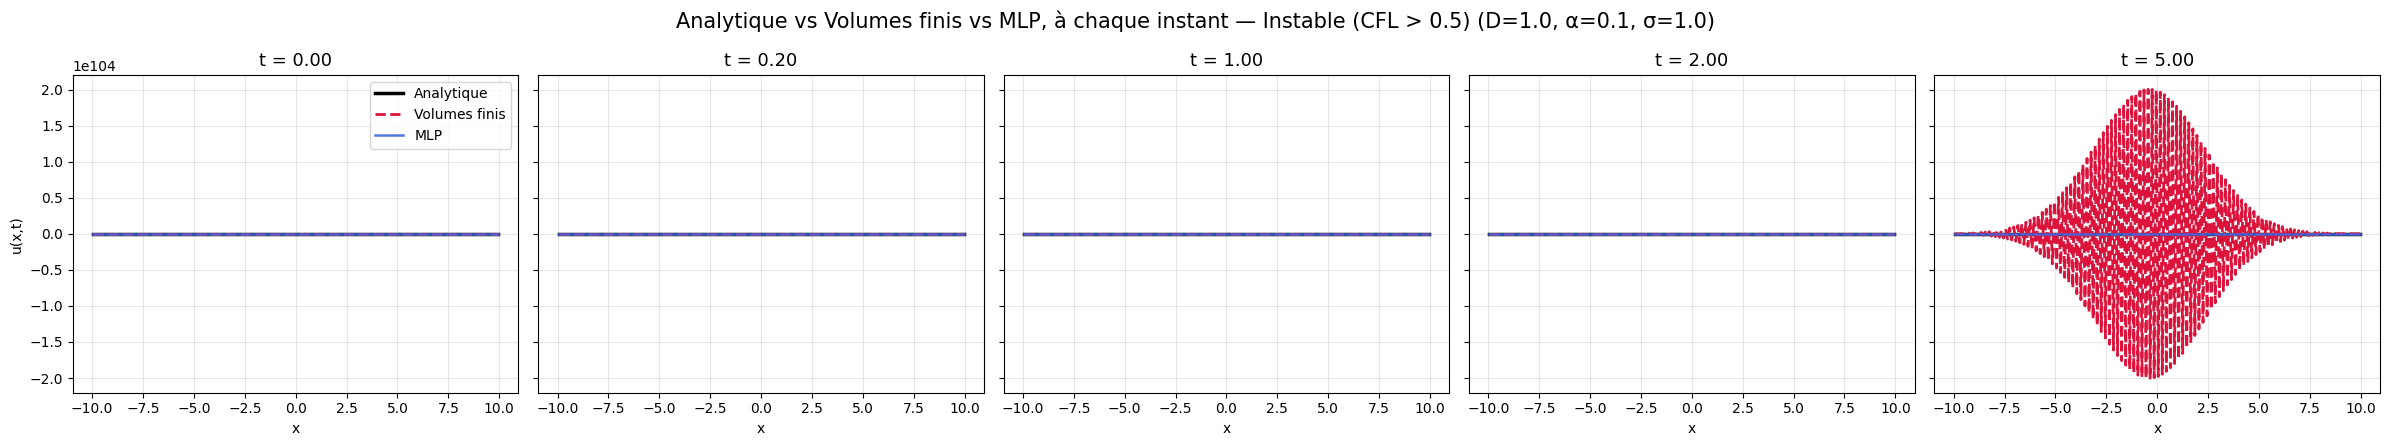

In [28]:
scenarios = {
    "Diffusion pure (alpha=0)":       dict(D=1.0, alpha=0.0,  sigma=1.0, clf=0.45),
    "Décroissance dominante":         dict(D=0.2, alpha=1.0,  sigma=1.0, clf=0.45),
    "Diffusion rapide":               dict(D=5.0, alpha=0.1,  sigma=1.0, clf=0.45),
    "Front raide":                    dict(D=1.0, alpha=0.1,  sigma=0.3, clf=0.45),
    "Front large":                    dict(D=1.0, alpha=0.1,  sigma=3.0, clf=0.45),
    "Diffusion lente":                dict(D=0.05, alpha=0.1, sigma=1.0, clf=0.45),
    "Décroissance nulle + rapide":    dict(D=5.0, alpha=0.0,  sigma=1.0, clf=0.45),
    "Décroissance forte + lente":     dict(D=0.05, alpha=1.0, sigma=1.0, clf=0.45),
    "CFL limite (0.5)":               dict(D=1.0, alpha=0.1,  sigma=1.0, clf=0.5),
    "Instable (CFL > 0.5)":           dict(D=1.0, alpha=0.1,  sigma=1.0, clf=0.6),
}

temps_a_tracer = [0.0, 0.2, 1.0, 2.0, 5.0]

for nom, p in scenarios.items():
    x_VF, t_VF, U_num = u_volume_finie(A=A, x0=x0, sigma=p['sigma'], D=p['D'],
                                        alpha=p['alpha'], L=L, T=T, Nx=Nx, clf=p['clf'])

    fig, axes = plt.subplots(1, len(temps_a_tracer), figsize=(24, 4.5), sharey=True)

    for col, ti in enumerate(temps_a_tracer):
        ax = axes[col]
        idx = np.argmin(np.abs(t_VF - ti))

        # Analytique
        u_exacte_ti = u_analytique(x_VF, t_VF[idx], A, x0, p['sigma'], p['D'], p['alpha'])

        # MLP
        x_gn = (x_VF - x_mean) / x_std
        t_gn = (np.full_like(x_VF, t_VF[idx]) - t_mean) / t_std
        Xg = torch.tensor(np.column_stack([x_gn, t_gn]), dtype=torch.float32)
        with torch.no_grad():
            u_log_pred = model(Xg).numpy().flatten() * u_std + u_mean
        u_pred = np.exp(u_log_pred) - eps

        ax.plot(x_VF, u_exacte_ti, color='black', linewidth=2.5, label='Analytique')
        ax.plot(x_VF, U_num[idx, :], color='crimson', linestyle='--', linewidth=2, label='Volumes finis')
        ax.plot(x_VF, u_pred, color='royalblue', linewidth=1.8, alpha=0.9, label='MLP')

        ax.set_title(f"t = {ti:.2f}", fontsize=13)
        ax.set_xlabel('x')
        ax.grid(True, alpha=0.3)
        if col == 0:
            ax.set_ylabel('u(x,t)')
            ax.legend(fontsize=10)

    plt.suptitle(f"Analytique vs Volumes finis vs MLP, à chaque instant — {nom} "
                 f"(D={p['D']}, α={p['alpha']}, σ={p['sigma']})", fontsize=15)
    plt.tight_layout()
    plt.savefig(f"comparaison_{nom.replace(' ', '_').replace('(', '').replace(')', '')}.png",
                dpi=300, bbox_inches='tight')
    plt.show()

## PINNs

In [185]:
class PINN(nn.Module):
    def __init__(self, hidden_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x):
        return self.net(x)

In [186]:
def pinn_residual(model,x,t):
    x = x.clone().requires_grad_(True)
    t = t.clone().requires_grad_(True)
    u_pred = model(torch.cat([x,t],dim=1))

    u_t = torch.autograd.grad(u_pred, t, grad_outputs = torch.ones_like(u_pred), create_graph=True)[0]
    u_x = torch.autograd.grad(u_pred, x, grad_outputs = torch.ones_like(u_pred), create_graph = True)[0]
    u_xx = torch.autograd.grad(u_x, x, grad_outputs = torch.ones_like(u_x), create_graph = True)[0]

    R = u_t - D*u_xx + alpha*u_pred
    return R

In [187]:
N_ic = 200
x_ic = np.random.uniform(-L, L, N_ic)
t_ic = np.zeros(N_ic)
u_ic = u_analytique(x_ic, t_ic, A, x0, sigma, D, alpha)

x_ic = torch.tensor(x_ic, dtype=torch.float32).view(-1,1)
t_ic = torch.tensor(t_ic, dtype=torch.float32).view(-1,1)
u_ic = torch.tensor(u_ic, dtype=torch.float32).view(-1,1)

N_bc = 200
t_bc = np.random.uniform(0, T, N_bc)
x_bc = np.where(np.arange(N_bc) < N_bc // 2, -L, L).astype(float)
u_bc = u_analytique(x_bc, t_bc, A, x0, sigma, D, alpha)

x_bc = torch.tensor(x_bc, dtype=torch.float32).view(-1,1)
t_bc = torch.tensor(t_bc, dtype=torch.float32).view(-1,1)
u_bc = torch.tensor(u_bc, dtype=torch.float32).view(-1,1)


In [188]:
x_data = torch.cat([x_ic, x_bc])
t_data = torch.cat([t_ic, t_bc])
u_data = torch.cat([u_ic, u_bc])



In [189]:
def pinn_loss(model, X_data, y_data, X_phys, lambda_pde,alpha = alpha, D = D):
    # Perte sur les données (CI + bords)
    y_pred_data = model(X_data)
    loss_data = nn.MSELoss()(y_pred_data, y_data)

    # Perte sur la physique (résidu EDP)
    pde_residual = pinn_residual(model, X_phys[:, 0:1], X_phys[:, 1:2])
    loss_phys = torch.mean(pde_residual**2)

    total_loss = loss_data + lambda_pde * loss_phys
    return total_loss, loss_data, loss_phys

In [190]:
epochs = 5000
lr = 1e-3
lambda_pde = 8.0
print_every = 250
hist = {'total_loss': [], 'data_loss': [], 'phys_loss': []}


In [191]:
def train(model, X_data, y_data, epochs=epochs, lr=lr, lambda_pde=lambda_pde):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    for epoch in range(epochs+1):
        model.train()
        optimizer.zero_grad()

        N_r = 1000
        x_r = torch.tensor(np.random.uniform(-L, L, N_r), dtype=torch.float32).view(-1,1)
        t_r = torch.tensor(np.random.uniform(0, T, N_r), dtype=torch.float32).view(-1,1)
        X_phys = torch.cat([x_r, t_r], dim=1)

        loss_total, loss_data, loss_phys = pinn_loss(model, X_data, y_data, X_phys, lambda_pde)
        loss_total.backward()
        optimizer.step()
        hist['total_loss'].append(loss_total.item())
        hist['data_loss'].append(loss_data.item())
        hist['phys_loss'].append(loss_phys.item())

        if epoch % print_every == 0:
            print(f"Epoch {epoch:4d} | Data: {loss_data.item():.6f} | Phys: {loss_phys.item():.6f} | Total: {loss_total.item():.6f}")

    
    return model

In [192]:
X_data = torch.cat([x_data, t_data], dim=1)

pinn = PINN(hidden_dim=32)
pinn = train(pinn, X_data, u_data)

Epoch    0 | Data: 0.009922 | Phys: 0.000281 | Total: 0.012168
Epoch  250 | Data: 0.000293 | Phys: 0.000008 | Total: 0.000359
Epoch  500 | Data: 0.000176 | Phys: 0.000010 | Total: 0.000256
Epoch  750 | Data: 0.000132 | Phys: 0.000005 | Total: 0.000175
Epoch 1000 | Data: 0.000105 | Phys: 0.000008 | Total: 0.000166
Epoch 1250 | Data: 0.000087 | Phys: 0.000005 | Total: 0.000127
Epoch 1500 | Data: 0.000068 | Phys: 0.000005 | Total: 0.000105
Epoch 1750 | Data: 0.000064 | Phys: 0.000003 | Total: 0.000085
Epoch 2000 | Data: 0.000049 | Phys: 0.000003 | Total: 0.000076
Epoch 2250 | Data: 0.000038 | Phys: 0.000003 | Total: 0.000065
Epoch 2500 | Data: 0.000034 | Phys: 0.000004 | Total: 0.000069
Epoch 2750 | Data: 0.000030 | Phys: 0.000002 | Total: 0.000049
Epoch 3000 | Data: 0.000023 | Phys: 0.000002 | Total: 0.000036
Epoch 3250 | Data: 0.000042 | Phys: 0.000002 | Total: 0.000057
Epoch 3500 | Data: 0.000016 | Phys: 0.000001 | Total: 0.000024
Epoch 3750 | Data: 0.000017 | Phys: 0.000002 | Total: 0

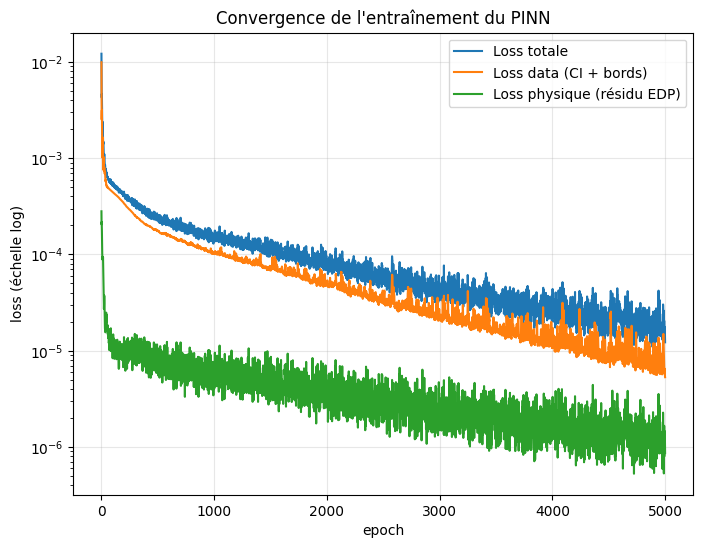

In [193]:
plt.figure(figsize=(8, 6))
plt.semilogy(hist['total_loss'], label='Loss totale')
plt.semilogy(hist['data_loss'], label='Loss data (CI + bords)')
plt.semilogy(hist['phys_loss'], label='Loss physique (résidu EDP)')
plt.xlabel('epoch')
plt.ylabel('loss (échelle log)')
plt.title("Convergence de l'entraînement du PINN")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('loss_PINN.png', dpi=300, bbox_inches='tight')
plt.show()

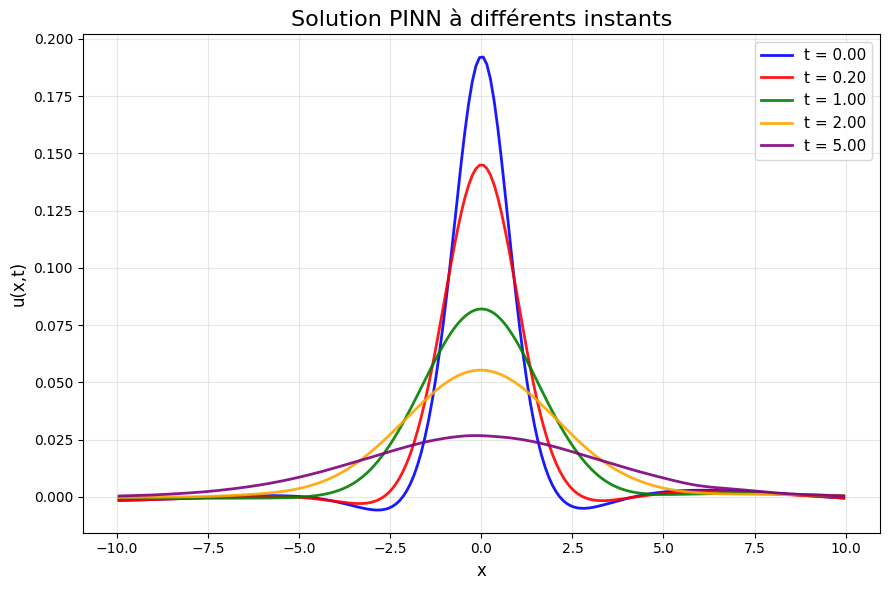

In [194]:
pinn.eval()
with torch.no_grad():
    xt_grille = torch.tensor(np.column_stack([X_mesh.ravel(), T_mesh.ravel()]), dtype=torch.float32)
    U_pinn_grille = pinn(xt_grille).numpy().reshape(X_mesh.shape)

temps_a_tracer = [1e-4, 0.2, 1, 2, T]
colors = ["blue", "red", "green", "orange", "purple"]

fig, ax = plt.subplots(figsize=(9, 6))

for c, ti in zip(colors, temps_a_tracer):
    idx = np.argmin(np.abs(t_grille - ti))
    ax.plot(x_grille, U_pinn_grille[idx, :], color=c, linewidth=2, alpha=0.9,
            label=f"t = {ti:.2f}")

ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('u(x,t)', fontsize=12)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)
ax.set_title("Solution PINN à différents instants", fontsize=16)

plt.tight_layout()
plt.savefig('comparaison_PINN.png', dpi=300, bbox_inches='tight')
plt.show()

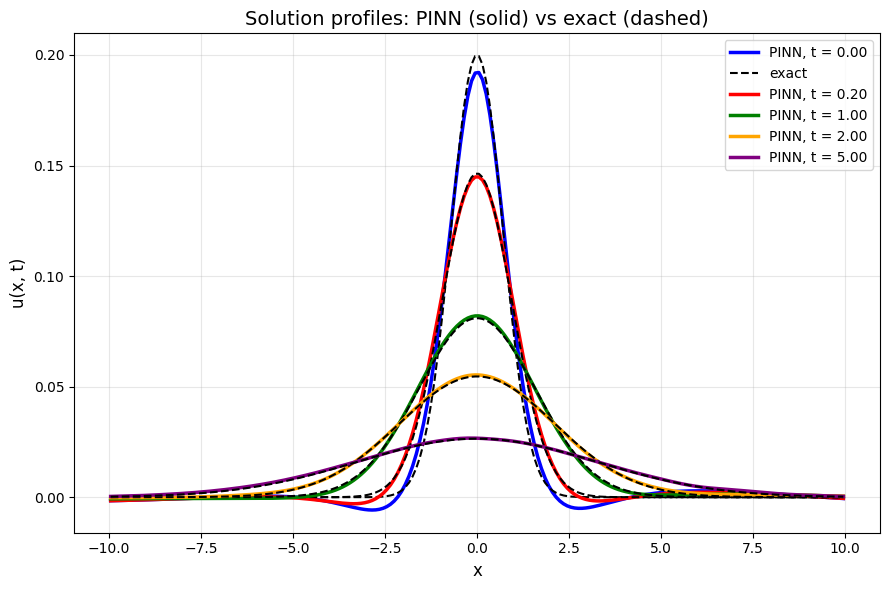

In [195]:
pinn.eval()
with torch.no_grad():
    xt_grille = torch.tensor(np.column_stack([X_mesh.ravel(), T_mesh.ravel()]), dtype=torch.float32)
    U_pinn_grille = pinn(xt_grille).numpy().reshape(X_mesh.shape)

temps_a_tracer = [1e-4, 0.2, 1, 2, T]
colors = ["blue", "red", "green", "orange", "purple"]

fig, ax = plt.subplots(figsize=(9, 6))

for i, (c, ti) in enumerate(zip(colors, temps_a_tracer)):
    idx = np.argmin(np.abs(t_grille - ti))
    U_exacte_ti = u_analytique(x_grille, t_grille[idx], A, x0, sigma, D, alpha)

    # Courbe PINN (pleine, colorée)
    ax.plot(x_grille, U_pinn_grille[idx, :], color=c, linewidth=2.5,
            label=f"PINN, t = {ti:.2f}")

    # Courbe exacte (pointillée noire) — une seule entrée dans la légende
    ax.plot(x_grille, U_exacte_ti, color='black', linestyle='--', linewidth=1.5,
            label="exact" if i == 0 else None)

ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('u(x, t)', fontsize=12)
ax.set_title("Solution profiles: PINN (solid) vs exact (dashed)", fontsize=14)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('comparaison_PINN.png', dpi=300, bbox_inches='tight')
plt.show()

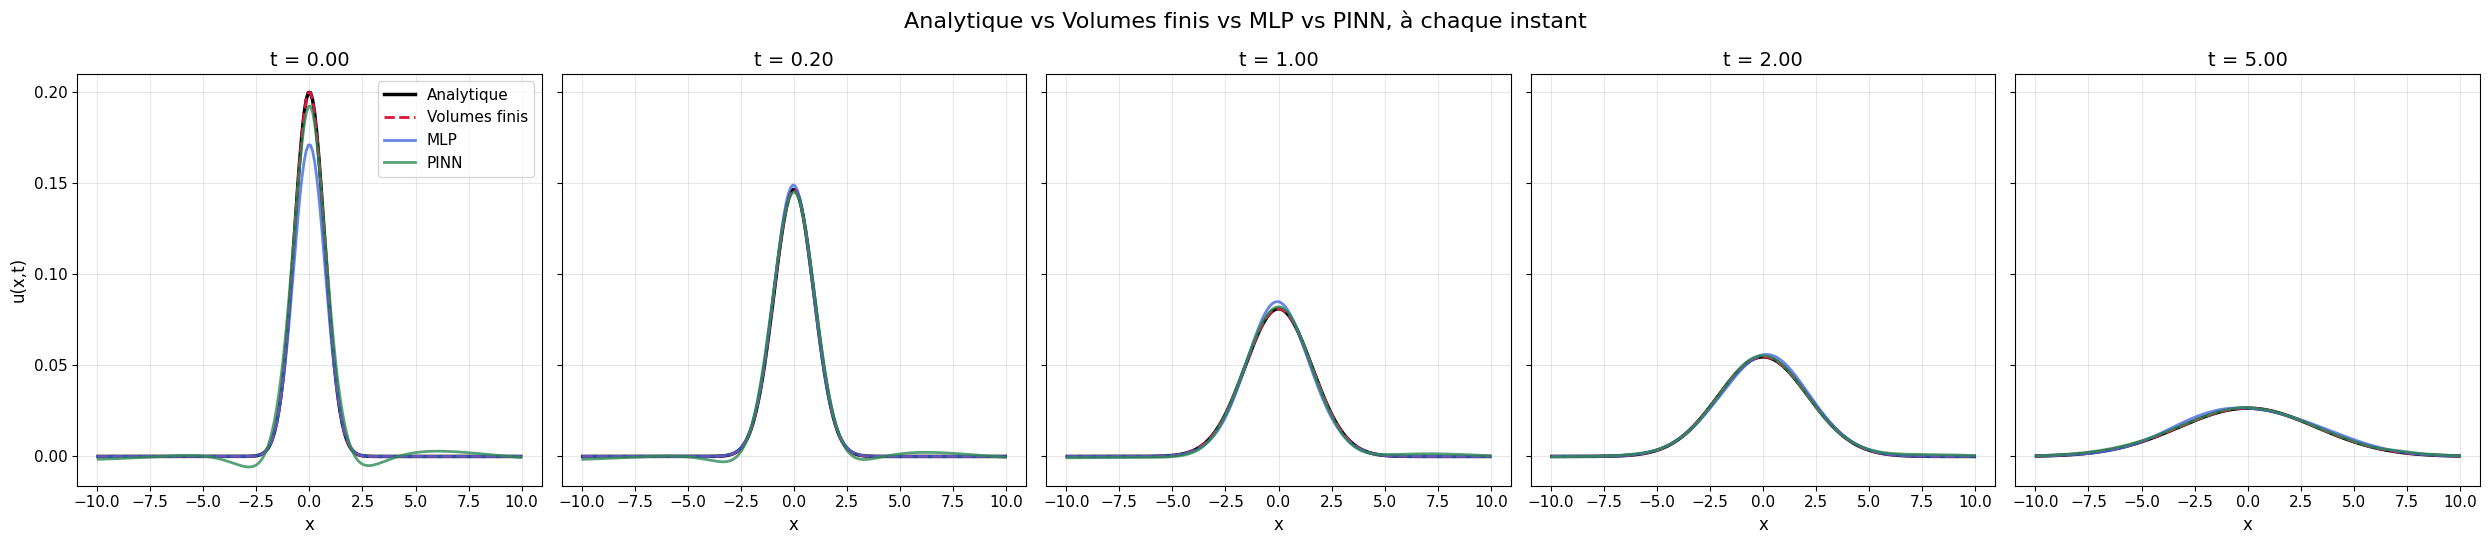

In [204]:
pinn.eval()
with torch.no_grad():
    xt_grille = torch.tensor(np.column_stack([X_mesh.ravel(), T_mesh.ravel()]),
                              dtype=torch.float32)
    U_pinn_grille = pinn(xt_grille).numpy().reshape(X_mesh.shape)

temps_a_tracer = [1e-4, 0.2, 1, 2, T]

fig, axes = plt.subplots(1, len(temps_a_tracer), figsize=(5*len(temps_a_tracer), 5.5), sharey=True)

for ax, ti in zip(axes, temps_a_tracer):
    idx = np.argmin(np.abs(t_grille - ti))
    U_exacte_ti = u_analytique(x_grille, t_grille[idx], A, x0, sigma, D, alpha)

    ax.plot(x_grille, U_exacte_ti, color='black', linewidth=2.5, label="Analytique")
    ax.plot(x_grille, U_vf_grille[idx, :], color='crimson', linestyle='--', linewidth=2, label="Volumes finis")
    ax.plot(x_grille, U_mlp_grille[idx, :], color='royalblue', linewidth=2, alpha=0.8, label="MLP")
    ax.plot(x_grille, U_pinn_grille[idx, :], color='seagreen', linewidth=2, alpha=0.8, label="PINN")

    ax.set_title(f"t = {ti:.2f}", fontsize=14)
    ax.set_xlabel('x', fontsize=12)
    ax.tick_params(labelsize=11)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('u(x,t)', fontsize=12)
axes[0].legend(fontsize=11)
plt.suptitle("Analytique vs Volumes finis vs MLP vs PINN, à chaque instant", fontsize=16)
plt.tight_layout()
plt.savefig('comparaison_4_methodes.png', dpi=300, bbox_inches='tight')
plt.show()

In [196]:
pinn.eval()
with torch.no_grad():
    u_pred_train = pinn(X_data)
    err_train = (u_pred_train - u_data).numpy()

MSE_train = np.mean(err_train**2)
print(f"Erreur sur points d'entraînement (CI+bords) | MSE = {MSE_train:.3e}")

Erreur sur points d'entraînement (CI+bords) | MSE = 5.520e-06


In [197]:
U_exacte_grille = np.array([u_analytique(x_grille, ti, A, x0, sigma, D, alpha) for ti in t_grille])
diff_grille = U_pinn_grille - U_exacte_grille

MSE_grille = np.mean(diff_grille**2)
L2_grille = np.sqrt(MSE_grille)
Linf_grille = np.max(np.abs(diff_grille))

print(f"Erreur sur grille complète (jamais vue)    | MSE = {MSE_grille:.3e}")
print(f"                                            | L2  = {L2_grille:.3e}")
print(f"                                            | L∞  = {Linf_grille:.3e}")

Erreur sur grille complète (jamais vue)    | MSE = 6.090e-07
                                            | L2  = 7.804e-04
                                            | L∞  = 1.007e-02


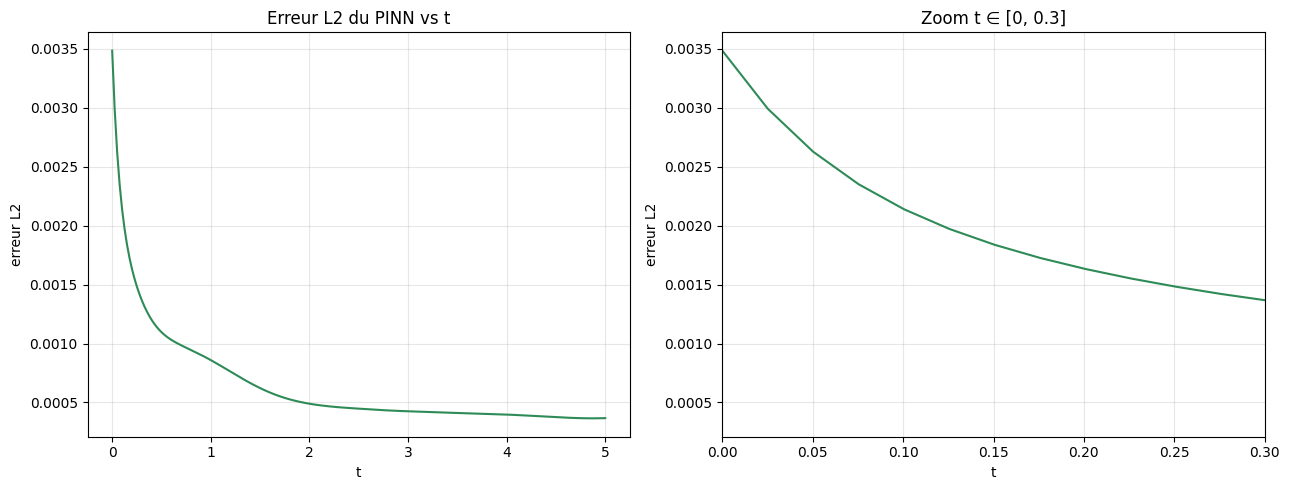

In [198]:
t_test_vals = np.linspace(0, T, 200)
x_grille_err = np.linspace(-L, L, Nx)

erreurs_L2_pinn, erreurs_Linf_pinn = [], []

pinn.eval()
for ti in t_test_vals:
    xt = torch.tensor(np.column_stack([x_grille_err, np.full_like(x_grille_err, ti)]),
                       dtype=torch.float32)
    with torch.no_grad():
        u_pred_g = pinn(xt).numpy().flatten()
    u_exacte_g = u_analytique(x_grille_err, ti, A, x0, sigma, D, alpha)
    diff = u_pred_g - u_exacte_g
    erreurs_L2_pinn.append(np.sqrt(np.mean(diff**2)))
    erreurs_Linf_pinn.append(np.max(np.abs(diff)))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(t_test_vals, erreurs_L2_pinn, color='seagreen')
axes[0].set_title("Erreur L2 du PINN vs t")
axes[1].plot(t_test_vals, erreurs_L2_pinn, color='seagreen')
axes[1].set_xlim(0, 0.3)
axes[1].set_title("Zoom t ∈ [0, 0.3]")
for ax in axes:
    ax.set_xlabel('t'); ax.set_ylabel('erreur L2'); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('erreur_PINN_vs_t.png', dpi=300, bbox_inches='tight')
plt.show()

In [199]:
def pinn_residual_scenario(model, x, t, D, alpha):
    x = x.clone().requires_grad_(True)
    t = t.clone().requires_grad_(True)
    u_pred = model(torch.cat([x, t], dim=1))

    u_t = torch.autograd.grad(u_pred, t, grad_outputs=torch.ones_like(u_pred), create_graph=True)[0]
    u_x = torch.autograd.grad(u_pred, x, grad_outputs=torch.ones_like(u_pred), create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x, grad_outputs=torch.ones_like(u_x), create_graph=True)[0]

    return u_t - D * u_xx + alpha * u_pred

def pinn_loss_scenario(model, X_data, y_data, X_phys, D, alpha, lambda_pde=1.0):
    loss_data = nn.MSELoss()(model(X_data), y_data)
    R = pinn_residual_scenario(model, X_phys[:, 0:1], X_phys[:, 1:2], D, alpha)
    loss_phys = torch.mean(R**2)
    return loss_data + lambda_pde * loss_phys, loss_data, loss_phys

In [200]:
def train_pinn_scenario(D, alpha, sigma, A=A, x0=x0, L=L, T=T,
                         epochs=2000, lr=1e-3, lambda_pde=1.0,
                         N_ic=200, N_bc=200, N_r=500):
    torch.manual_seed(0)
    model = PINN(hidden_dim=32)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    x_ic = np.random.uniform(-L, L, N_ic)
    t_ic = np.zeros(N_ic)
    u_ic = u_analytique(x_ic, t_ic, A, x0, sigma, D, alpha)

    t_bc = np.random.uniform(0, T, N_bc)
    x_bc = np.where(np.arange(N_bc) < N_bc // 2, -L, L).astype(float)
    u_bc = u_analytique(x_bc, t_bc, A, x0, sigma, D, alpha)

    x_data = torch.tensor(np.concatenate([x_ic, x_bc]), dtype=torch.float32).view(-1, 1)
    t_data = torch.tensor(np.concatenate([t_ic, t_bc]), dtype=torch.float32).view(-1, 1)
    u_data = torch.tensor(np.concatenate([u_ic, u_bc]), dtype=torch.float32).view(-1, 1)
    X_data = torch.cat([x_data, t_data], dim=1)

    for epoch in range(epochs):
        optimizer.zero_grad()
        x_r = torch.tensor(np.random.uniform(-L, L, N_r), dtype=torch.float32).view(-1, 1)
        t_r = torch.tensor(np.random.uniform(0, T, N_r), dtype=torch.float32).view(-1, 1)
        X_phys = torch.cat([x_r, t_r], dim=1)

        loss_total, _, _ = pinn_loss_scenario(model, X_data, u_data, X_phys, D, alpha, lambda_pde)
        loss_total.backward()
        optimizer.step()

    return model

espace de temps 0.004500000000000001 espace de position 0.1


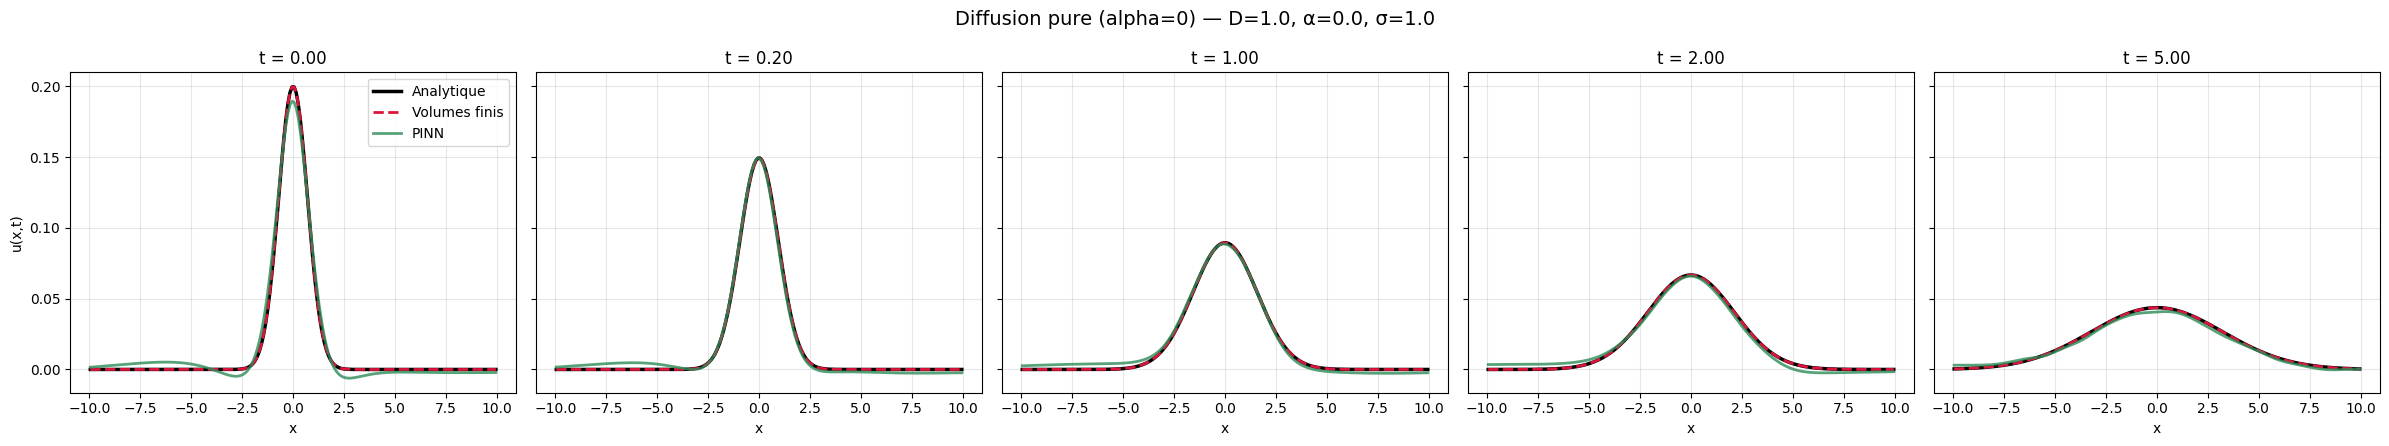

espace de temps 0.022500000000000006 espace de position 0.1


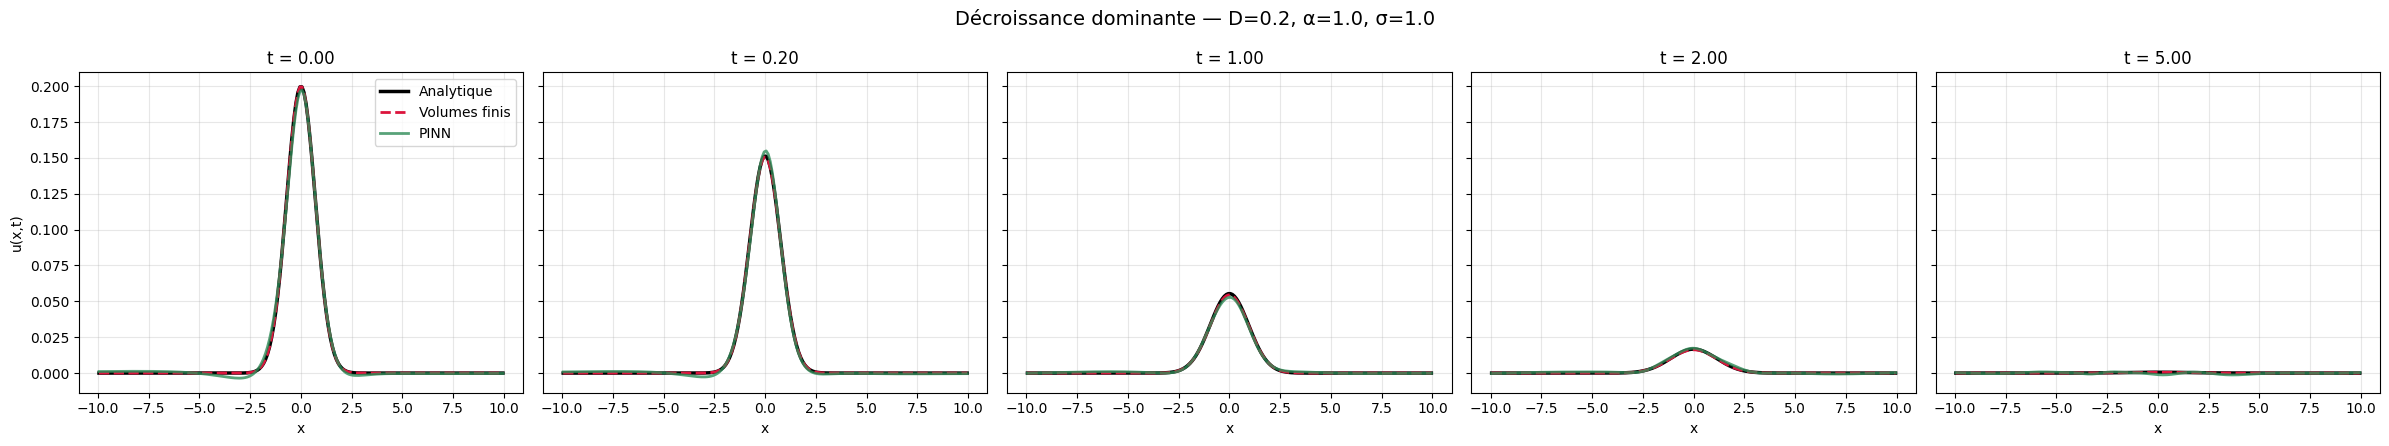

espace de temps 0.0009000000000000003 espace de position 0.1


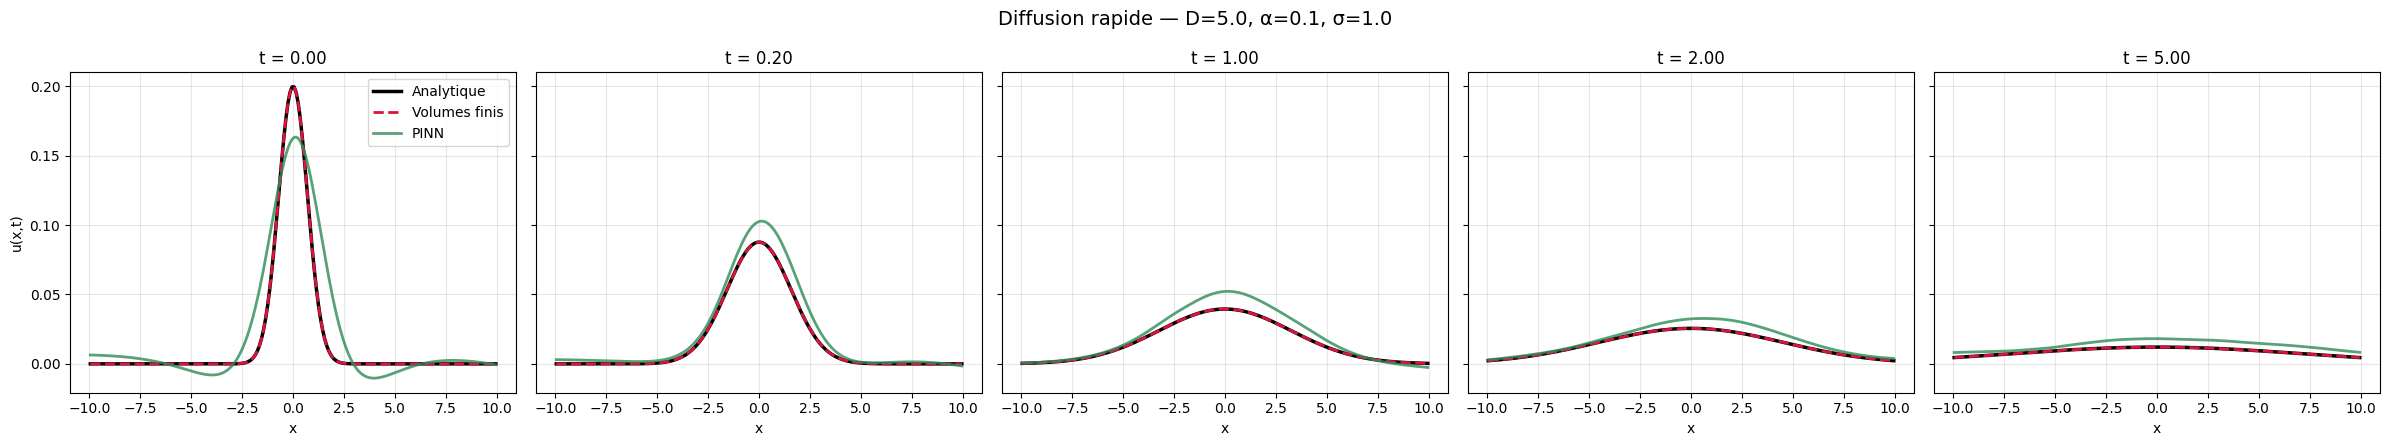

espace de temps 0.004500000000000001 espace de position 0.1


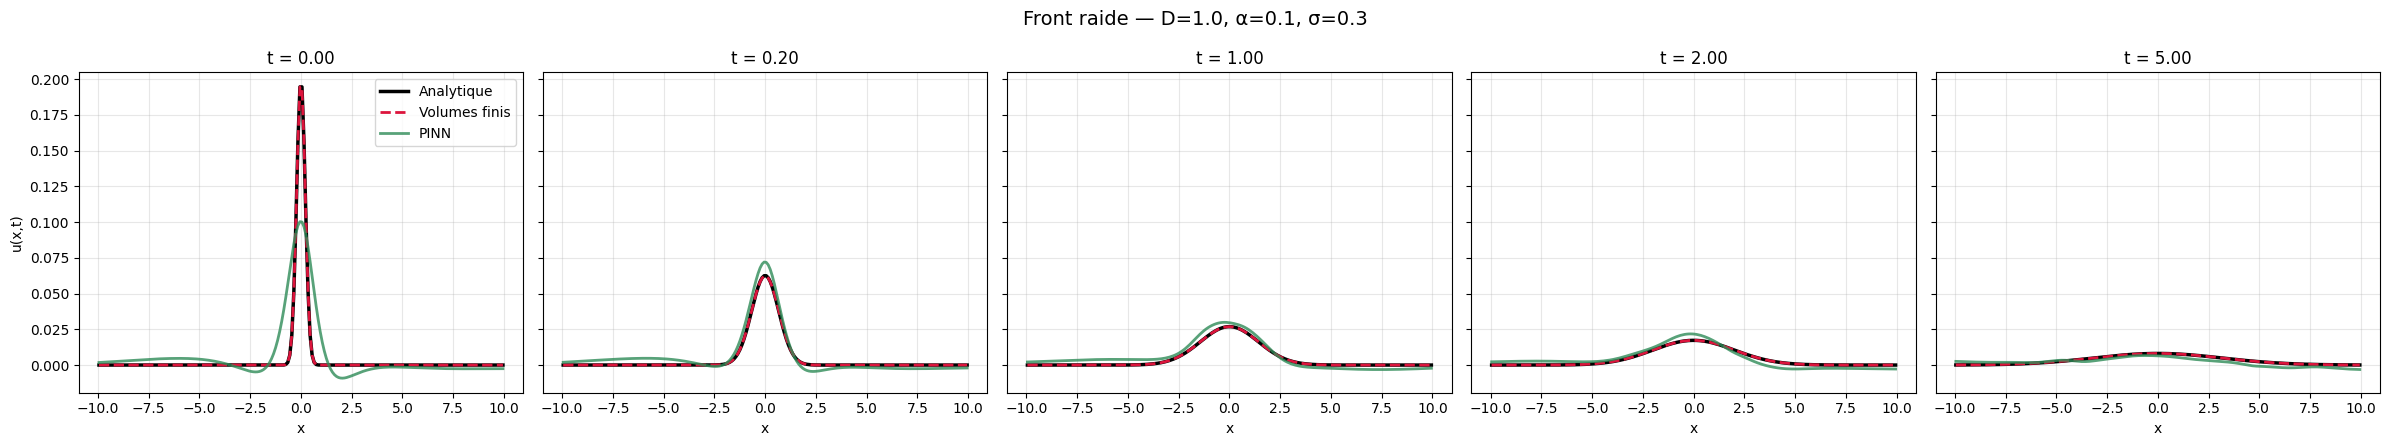

espace de temps 0.004500000000000001 espace de position 0.1


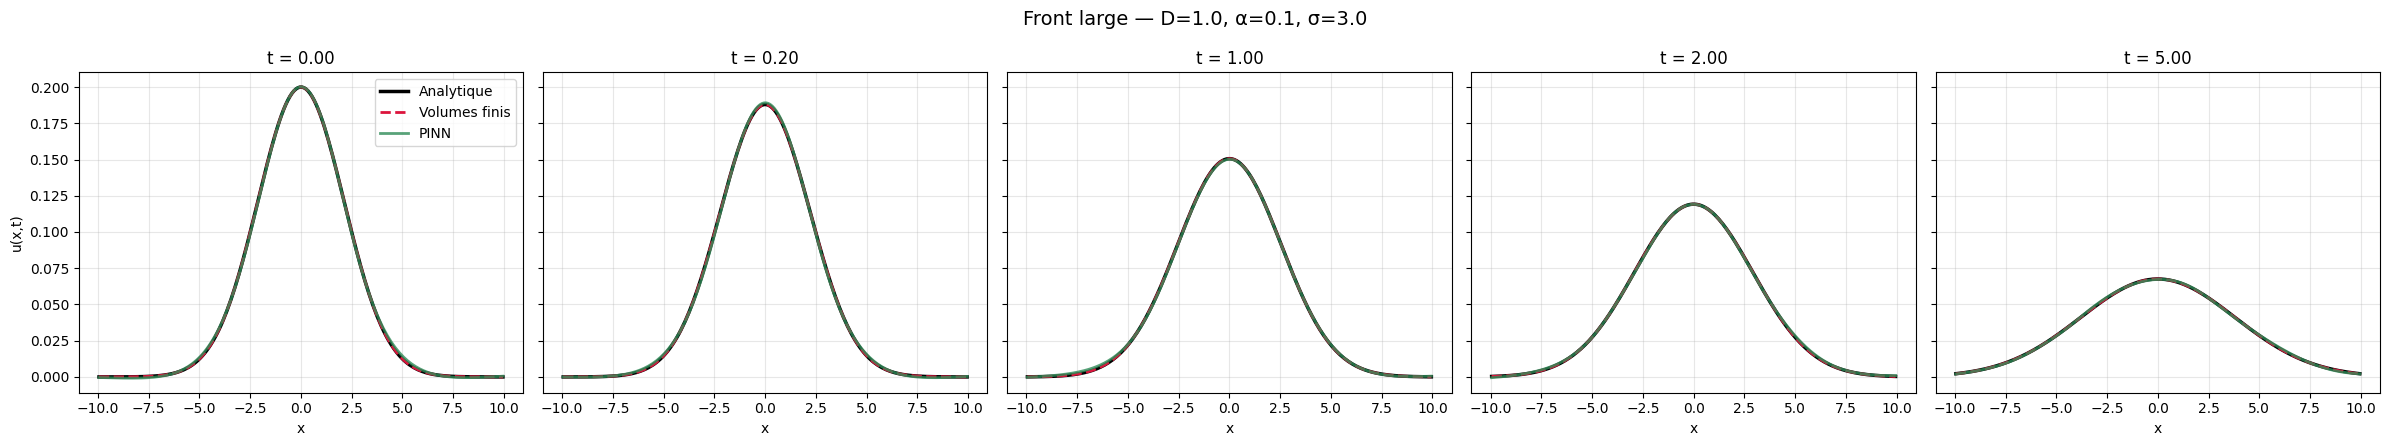

espace de temps 0.09000000000000002 espace de position 0.1


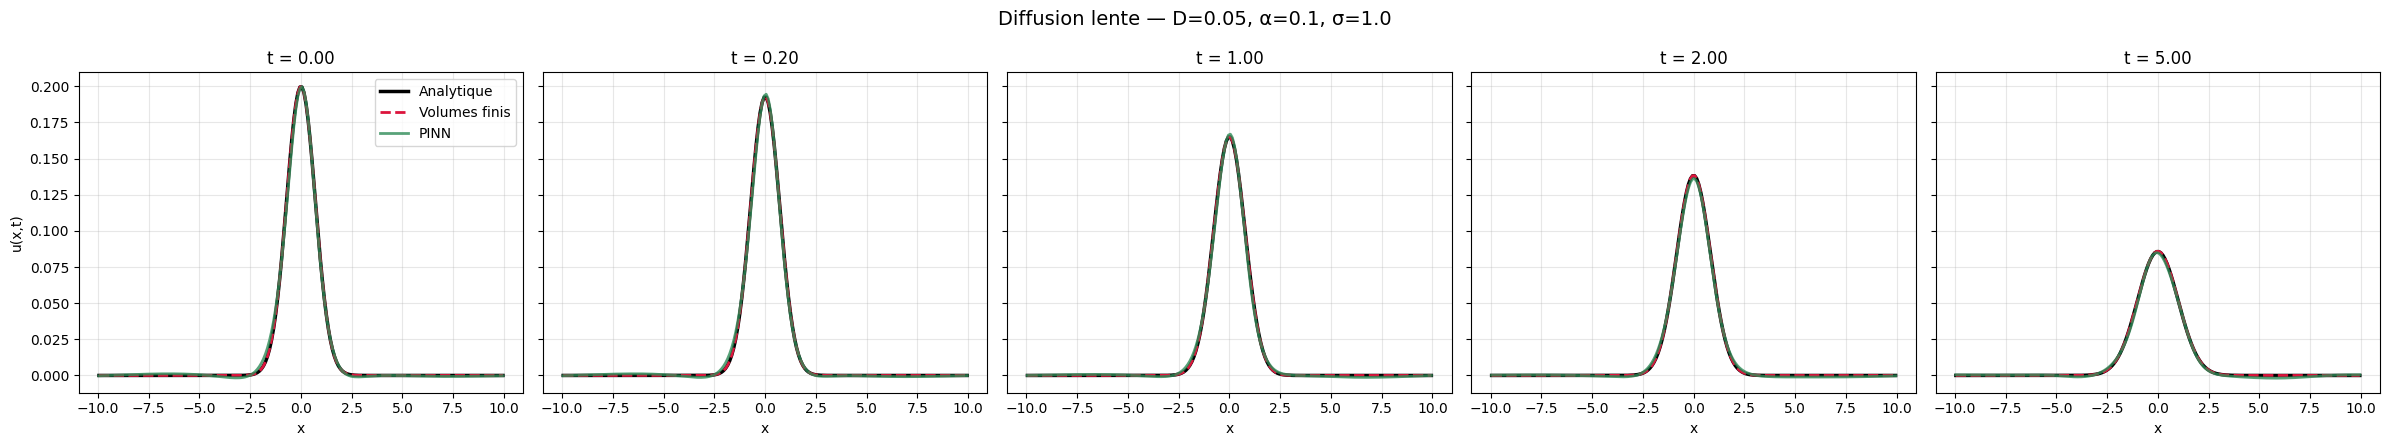

espace de temps 0.0009000000000000003 espace de position 0.1


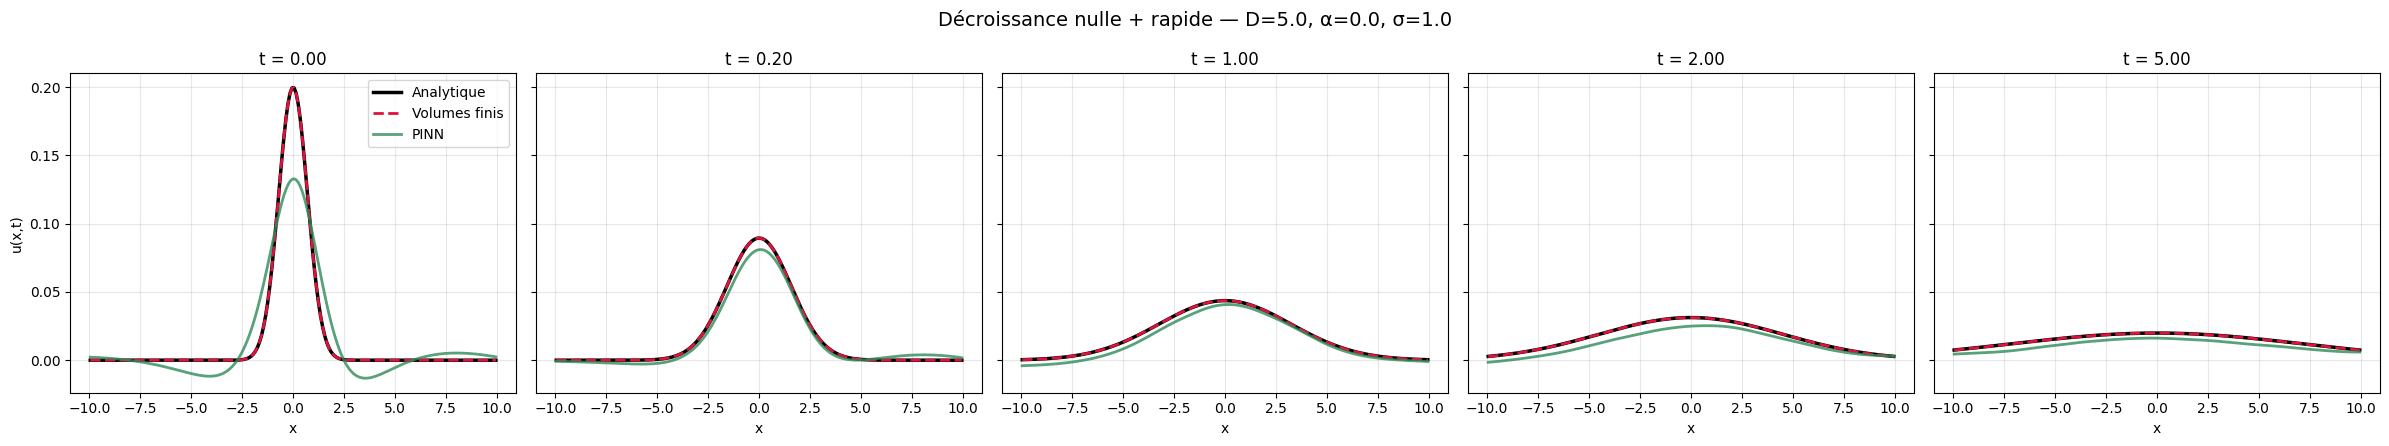

espace de temps 0.09000000000000002 espace de position 0.1


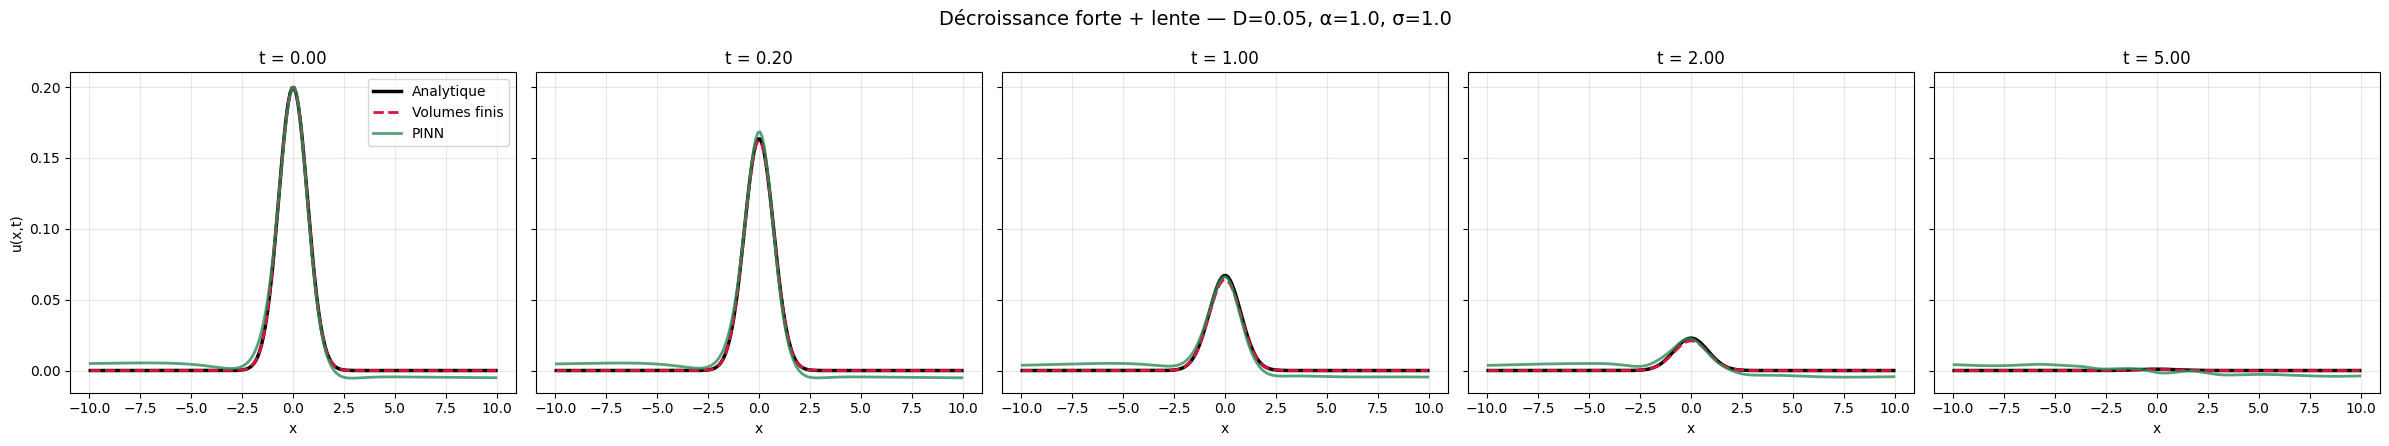

espace de temps 0.005000000000000001 espace de position 0.1


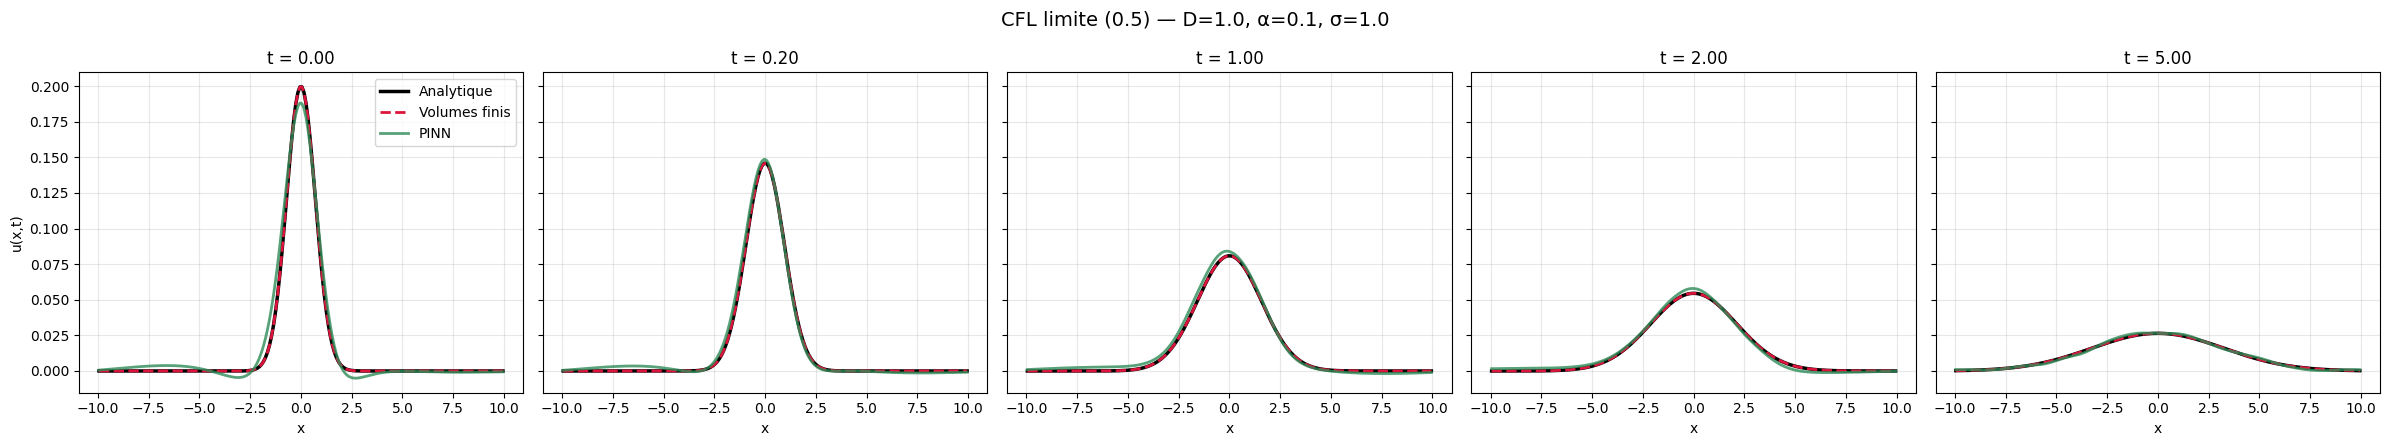

espace de temps 0.006000000000000001 espace de position 0.1


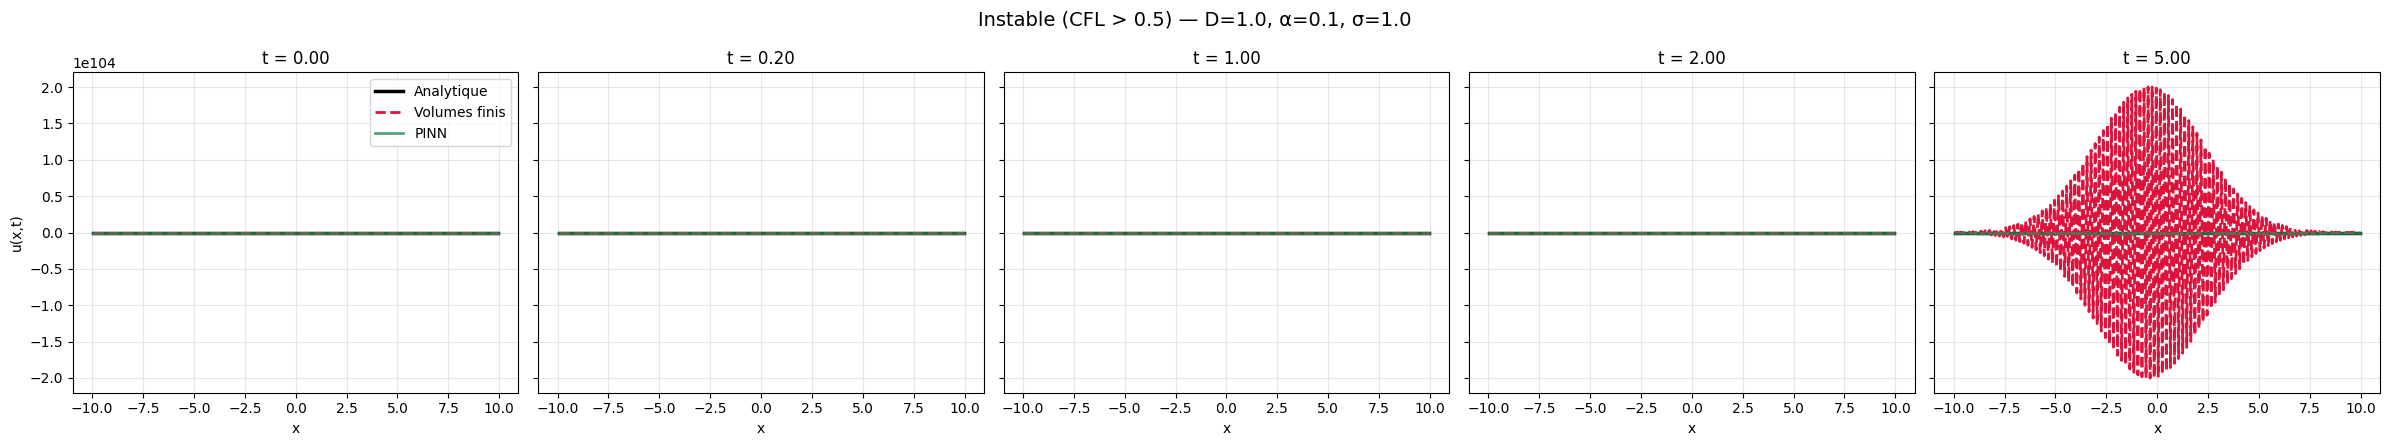

In [201]:
temps_a_tracer = [1e-4, 0.2, 1, 2, T]

for nom, p in scenarios.items():
    D_s, alpha_s, sigma_s, clf_s = p["D"], p["alpha"], p["sigma"], p["clf"]

    # Volumes finis + analytique pour ce scénario (comme votre cellule 47)
    x_VF, t_VF, U_num = u_volume_finie(A=A, x0=x0, sigma=sigma_s, D=D_s,
                                        alpha=alpha_s, L=L, T=T, Nx=Nx, clf=clf_s)

    # PINN entraîné spécifiquement pour ce scénario
    pinn_s = train_pinn_scenario(D=D_s, alpha=alpha_s, sigma=sigma_s, epochs=2000)

    fig, axes = plt.subplots(1, len(temps_a_tracer), figsize=(24, 4.5), sharey=True)

    for col, ti in enumerate(temps_a_tracer):
        ax = axes[col]
        idx = np.argmin(np.abs(t_VF - ti))
        u_exacte_ti = u_analytique(x_VF, t_VF[idx], A, x0, sigma_s, D_s, alpha_s)

        pinn_s.eval()
        with torch.no_grad():
            xt = torch.tensor(np.column_stack([x_VF, np.full_like(x_VF, t_VF[idx])]),
                               dtype=torch.float32)
            u_pinn_ti = pinn_s(xt).numpy().flatten()

        ax.plot(x_VF, u_exacte_ti, color='black', linewidth=2.5, label='Analytique')
        ax.plot(x_VF, U_num[idx, :], color='crimson', linestyle='--', linewidth=2, label='Volumes finis')
        ax.plot(x_VF, u_pinn_ti, color='seagreen', linewidth=2, alpha=0.8, label='PINN')

        ax.set_title(f"t = {ti:.2f}", fontsize=12)
        ax.set_xlabel('x'); ax.grid(True, alpha=0.3)

    axes[0].set_ylabel('u(x,t)')
    axes[0].legend(fontsize=10)
    fig.suptitle(f"{nom} — D={D_s}, α={alpha_s}, σ={sigma_s}", fontsize=14)
    plt.tight_layout()
    plt.savefig(f'scenario_PINN_{nom[:15].replace(" ", "_")}.png', dpi=200, bbox_inches='tight')
    plt.show()